   Bin  TotalReq_min  TotalReq_max  \
0    0     1560093.0     2187465.0   
1    1     2206486.0     2723293.0   
2    2     2886895.0     3455809.0   
3    3     3463664.0     4093695.0   
4    4     4098771.0     4730512.0   
5    5     4732627.0     5364723.0   
6    6     5365763.0     5999064.0   

                                    ErrorRate_counts  Num_Rows  
0                                          {0.0: 58}        58  
1                                          {0.0: 34}        34  
2                   {0.0: 51, 0.0001857820961793: 1}        52  
3  {0.0: 275, 0.0078944252200571: 1, 0.0001079858...       285  
4  {0.0: 110, 0.001041430175231: 1, 0.00010572825...       158  
5  {0.0: 235, 0.000290974752952: 1, 0.00016609571...       607  
6  {0.0: 364, 0.0017333221476277: 1, 0.0086787249...       985  
250
Not enough distinct ErrorRate values in bin 0. Falling back to probabilistic bootstrapping.


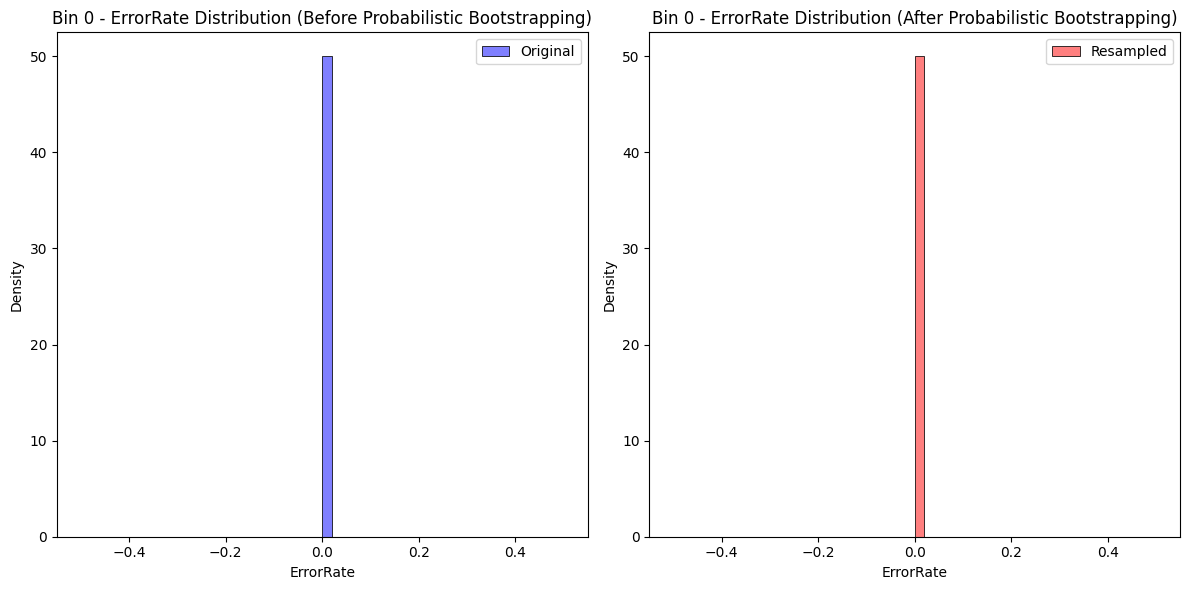

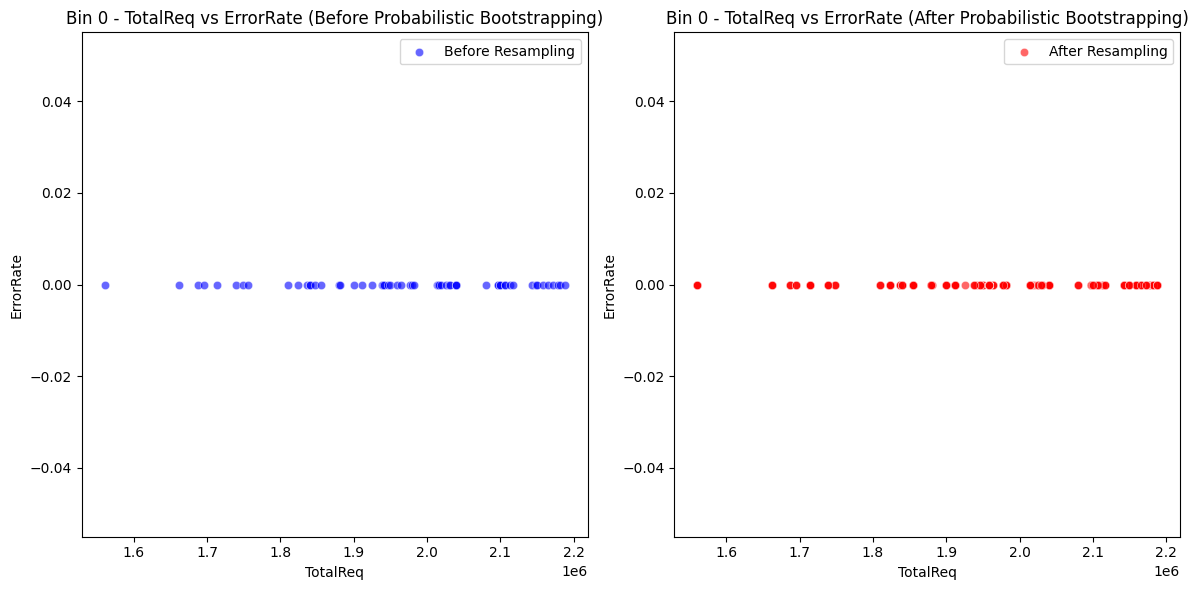

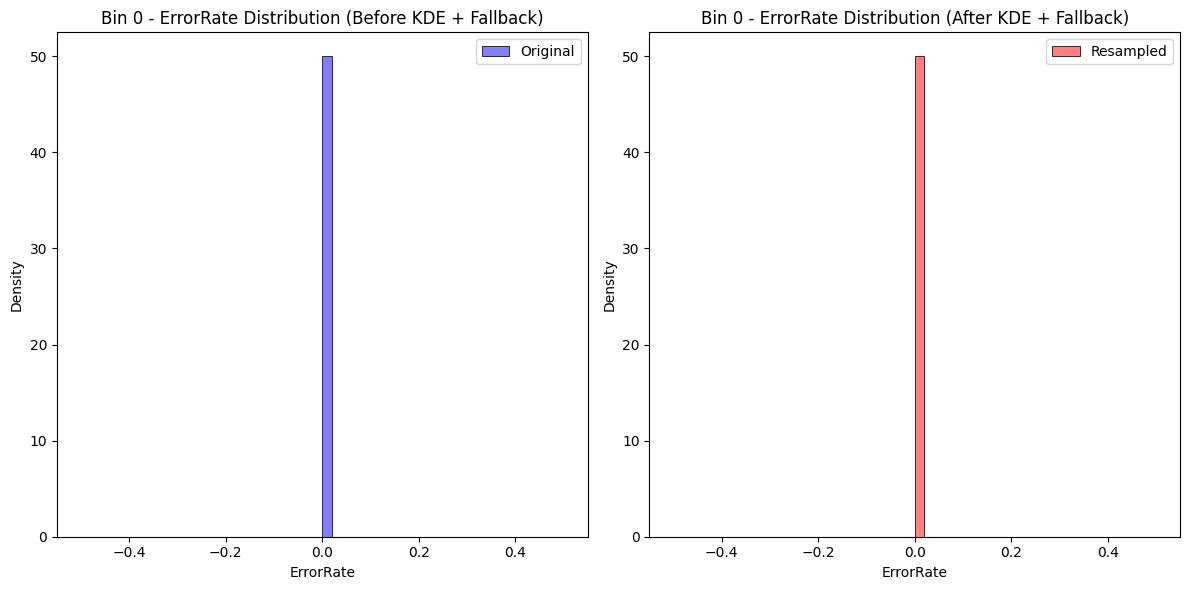

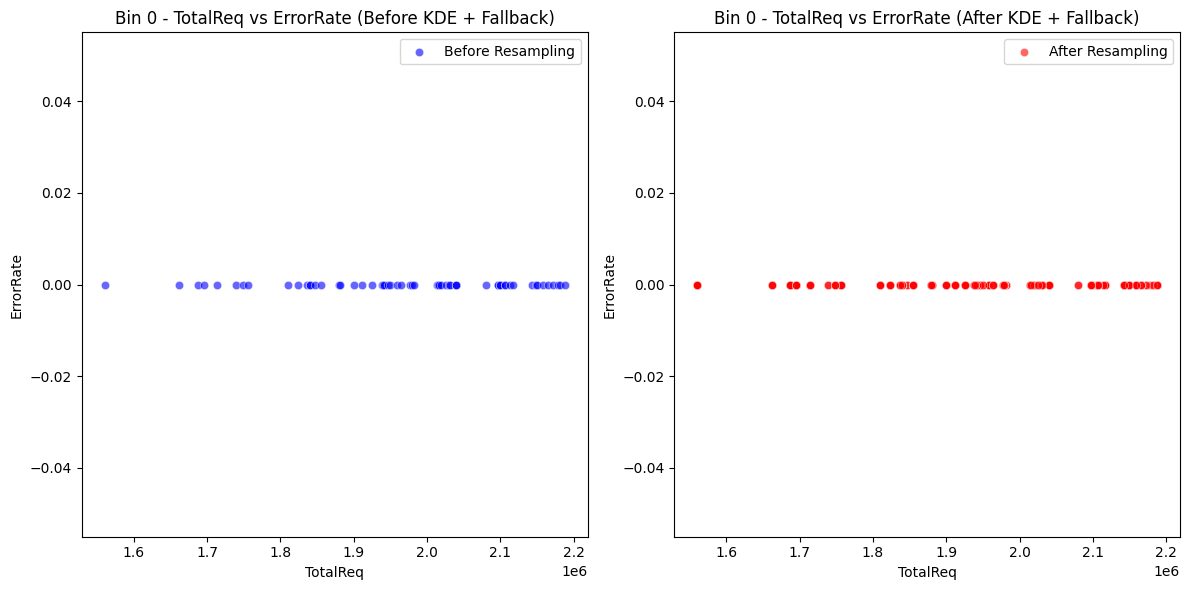

250
Not enough distinct ErrorRate values in bin 1. Falling back to probabilistic bootstrapping.


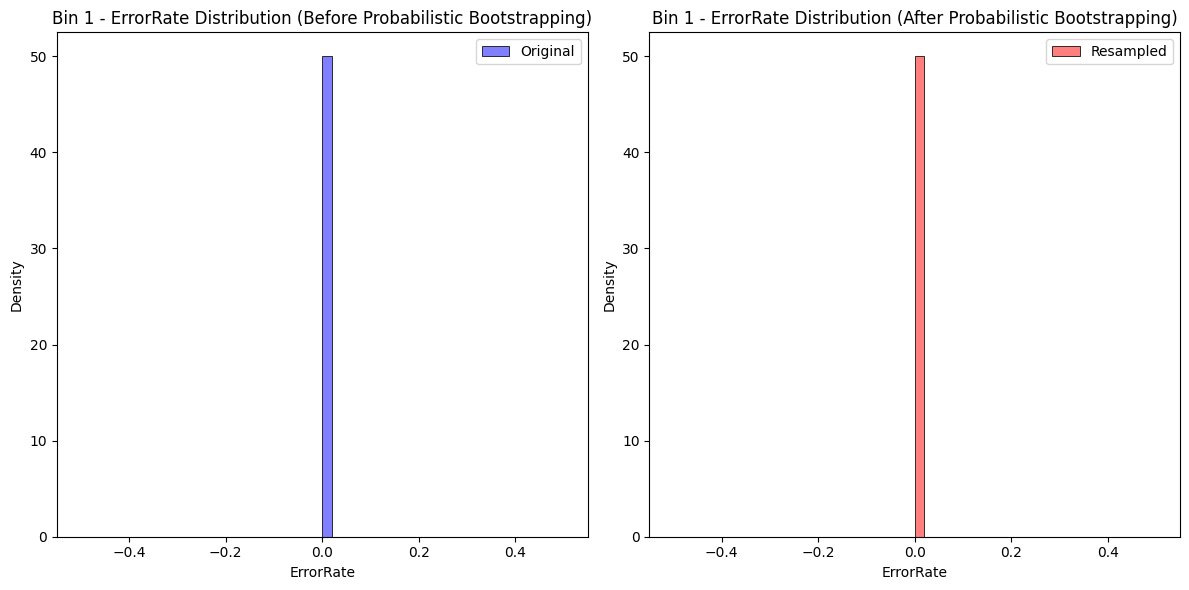

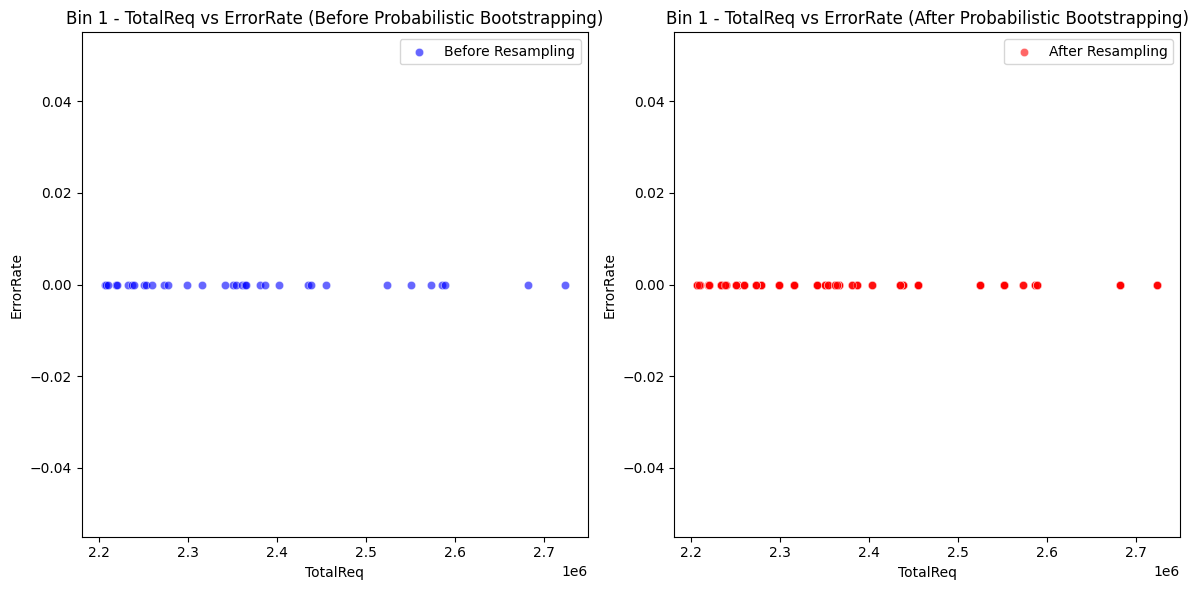

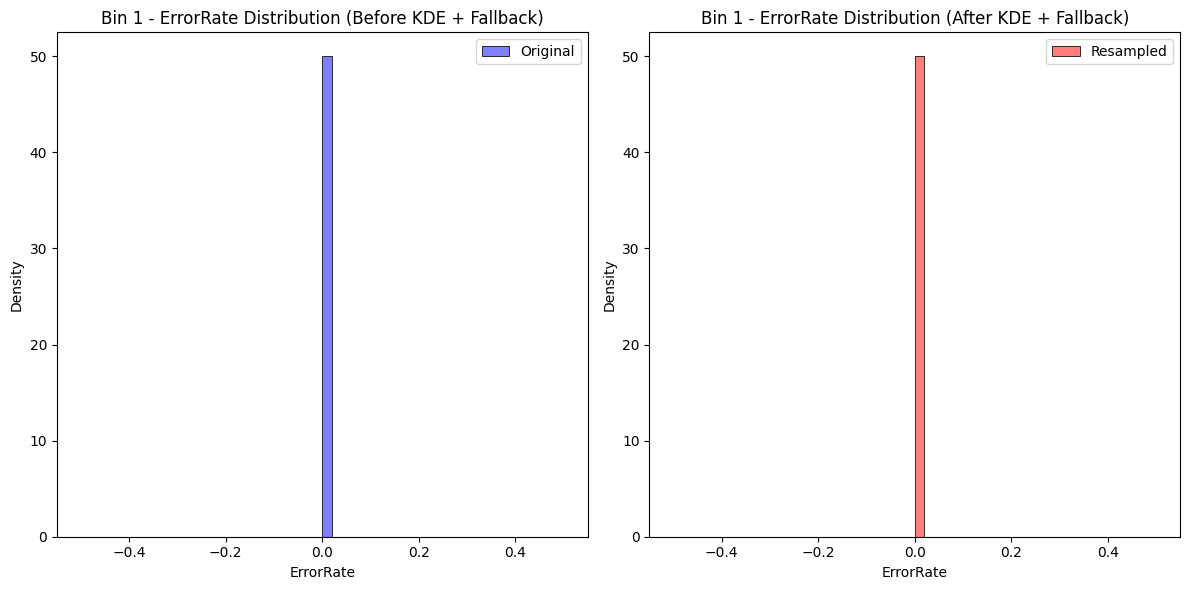

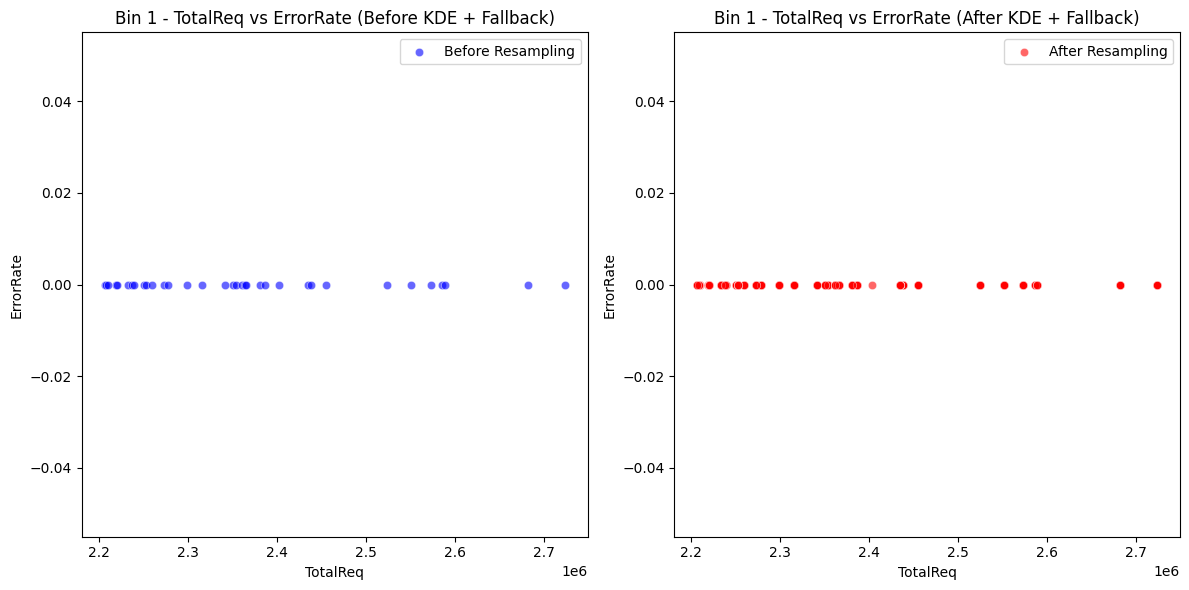

250


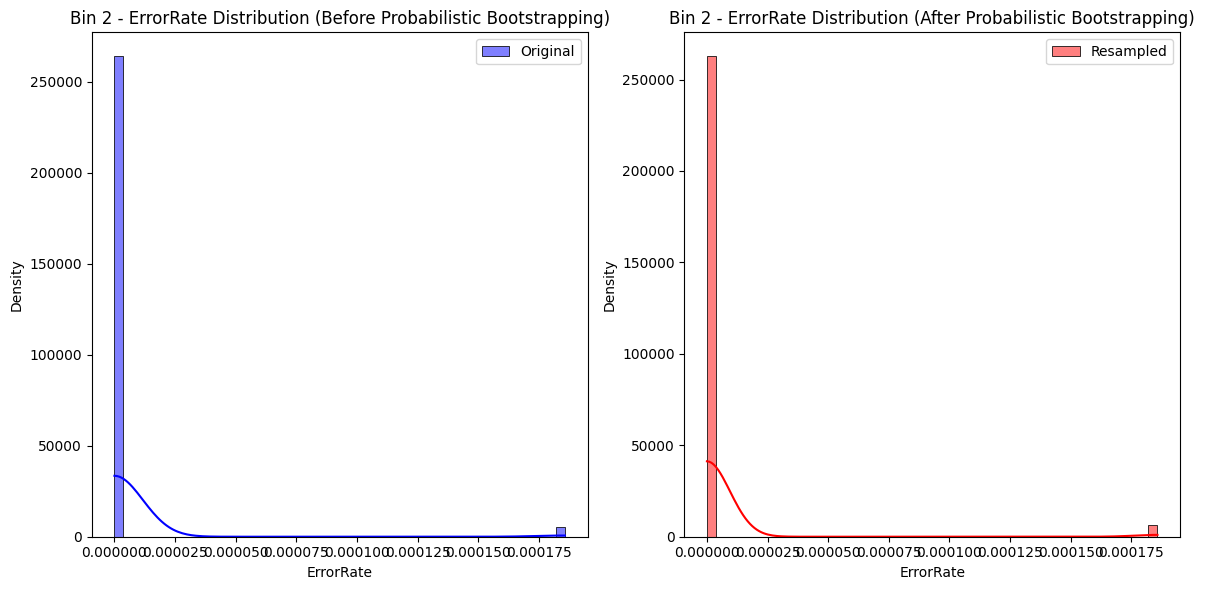

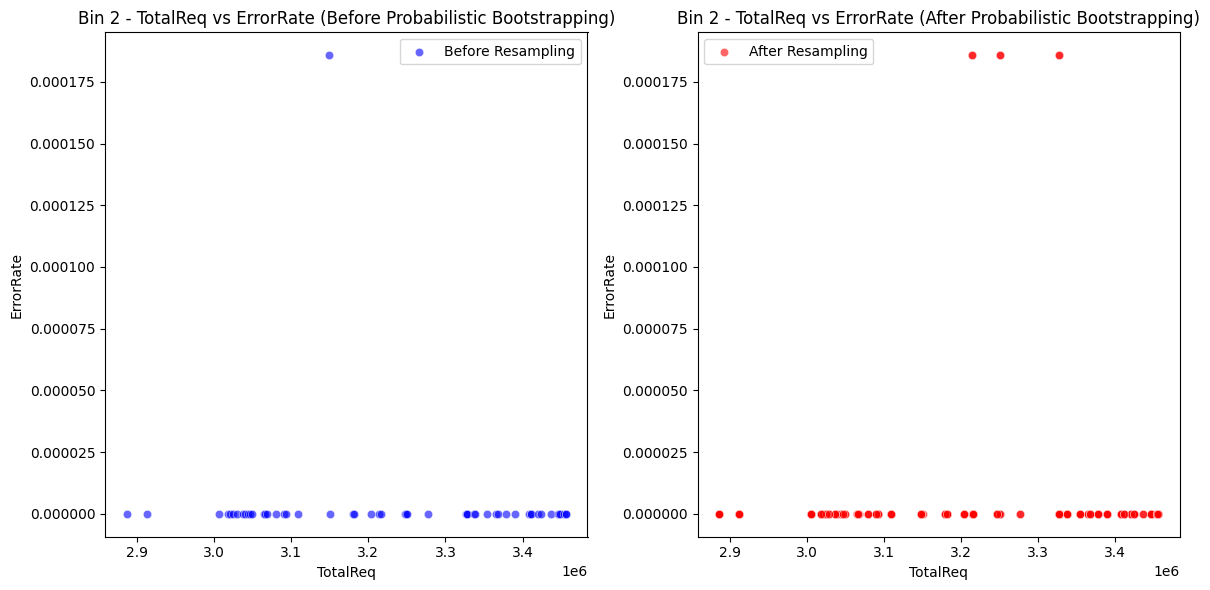

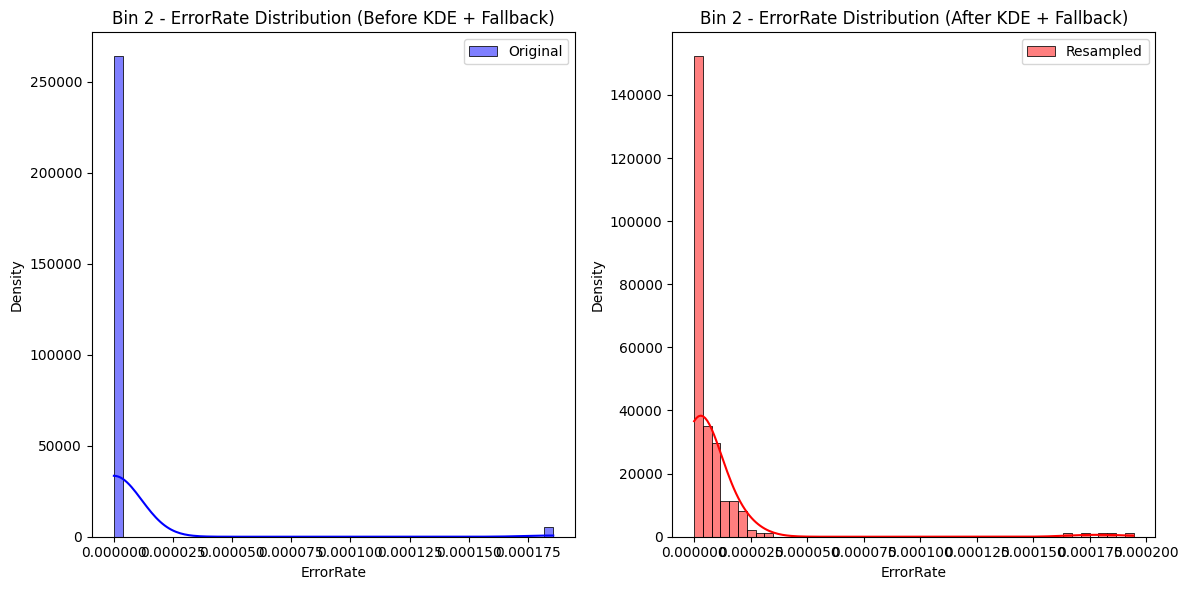

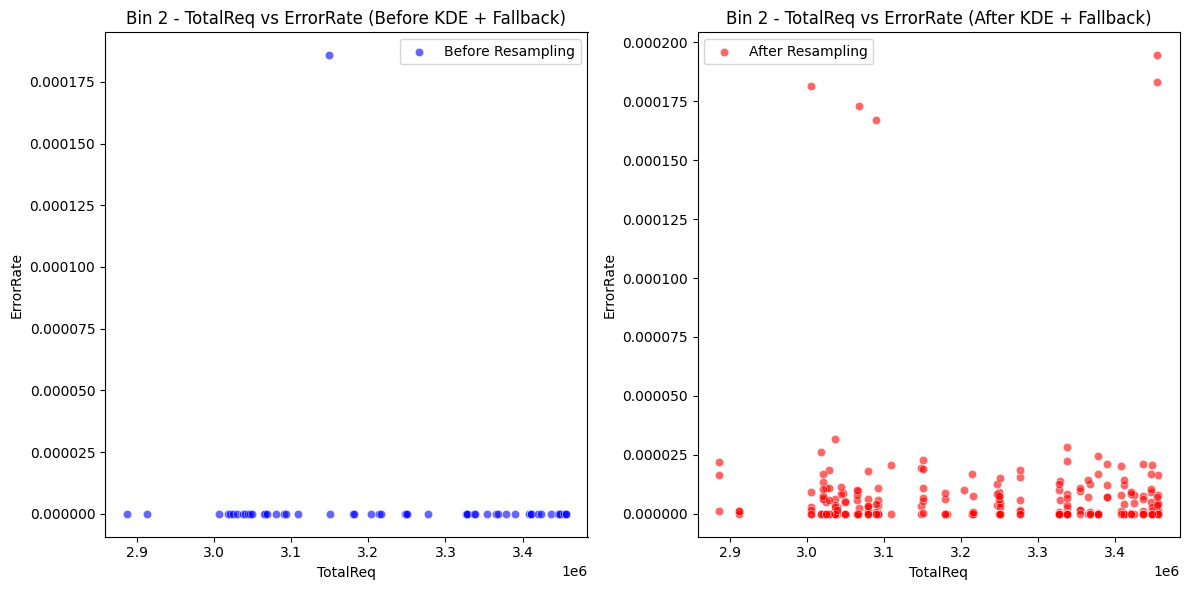

250


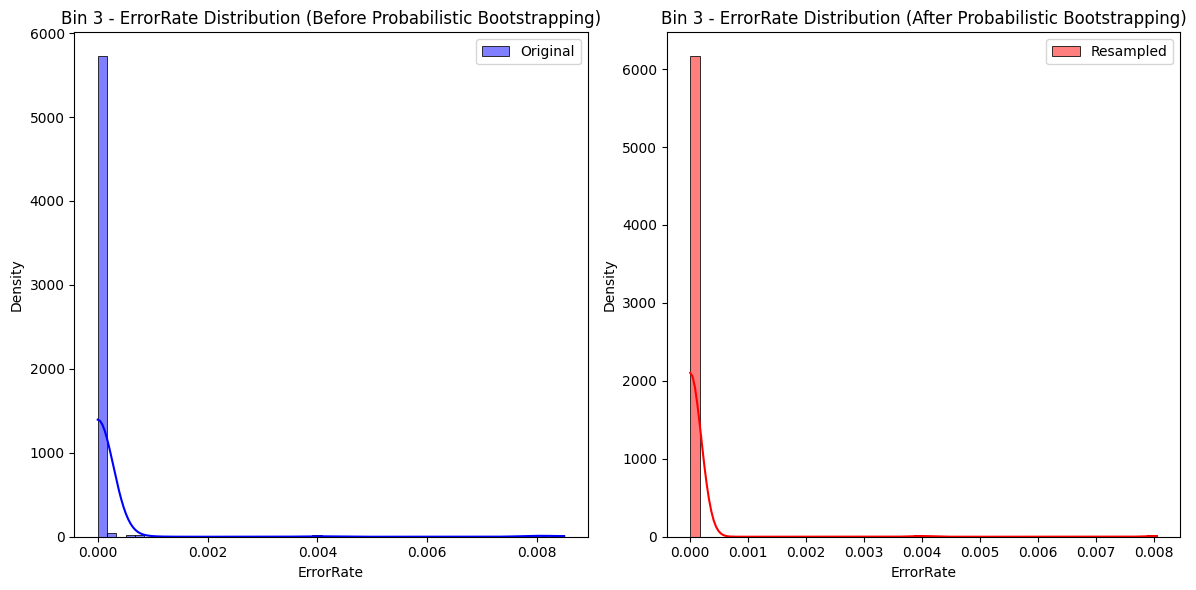

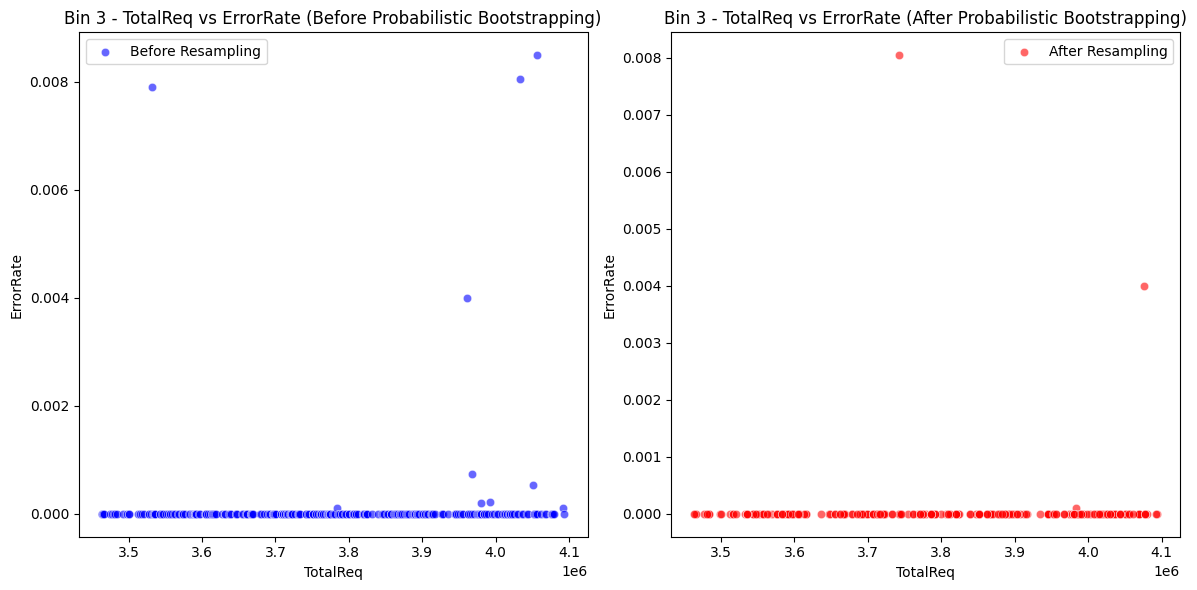

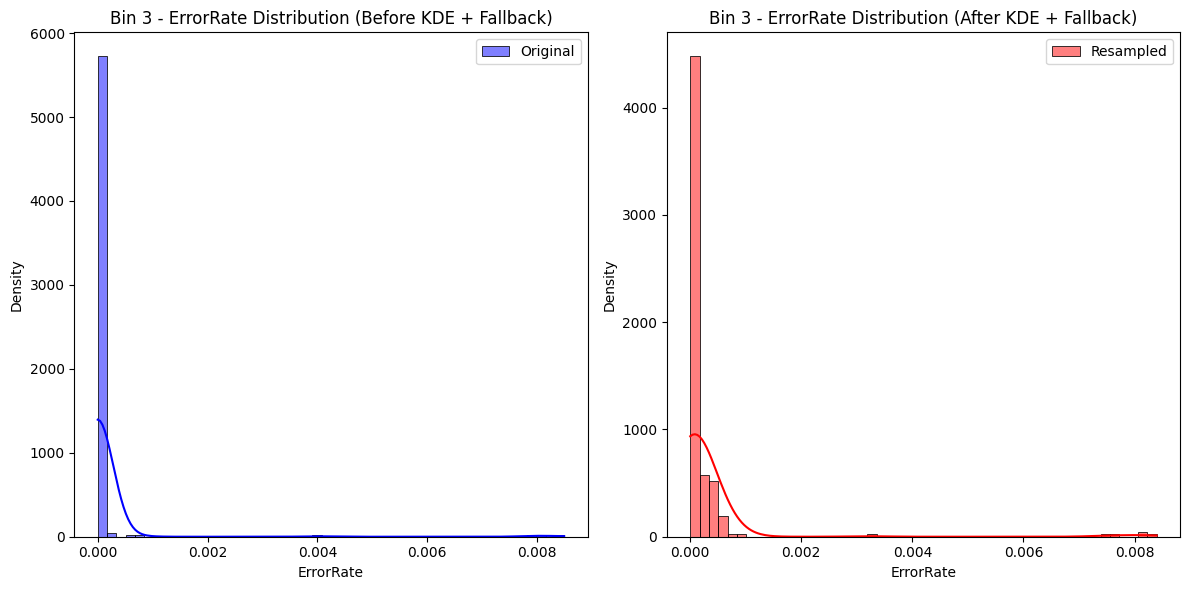

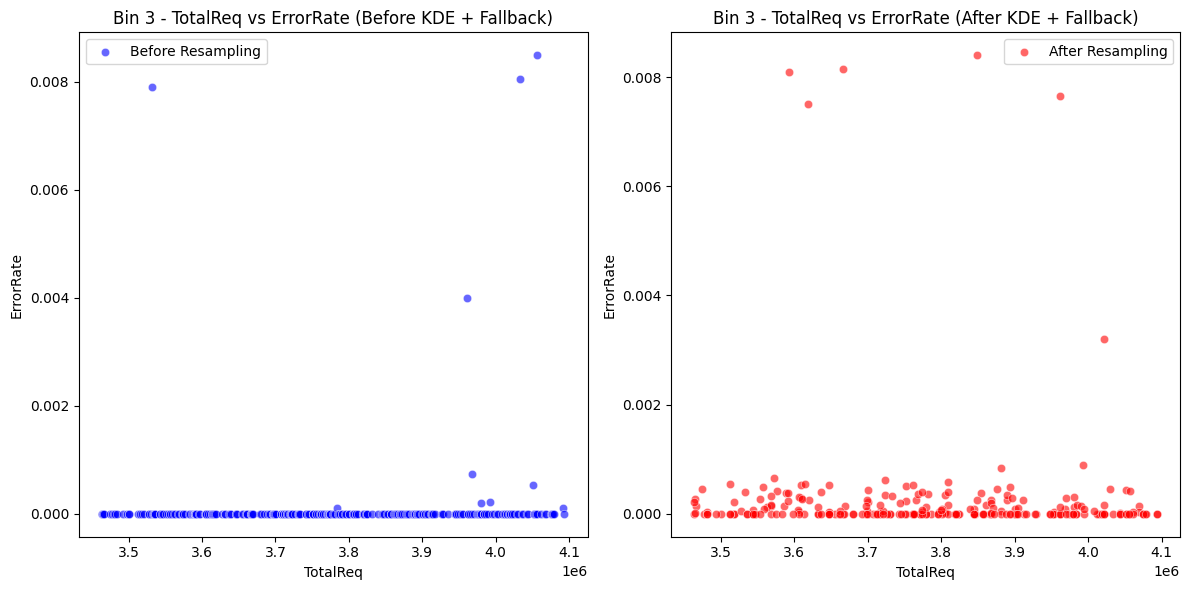

250


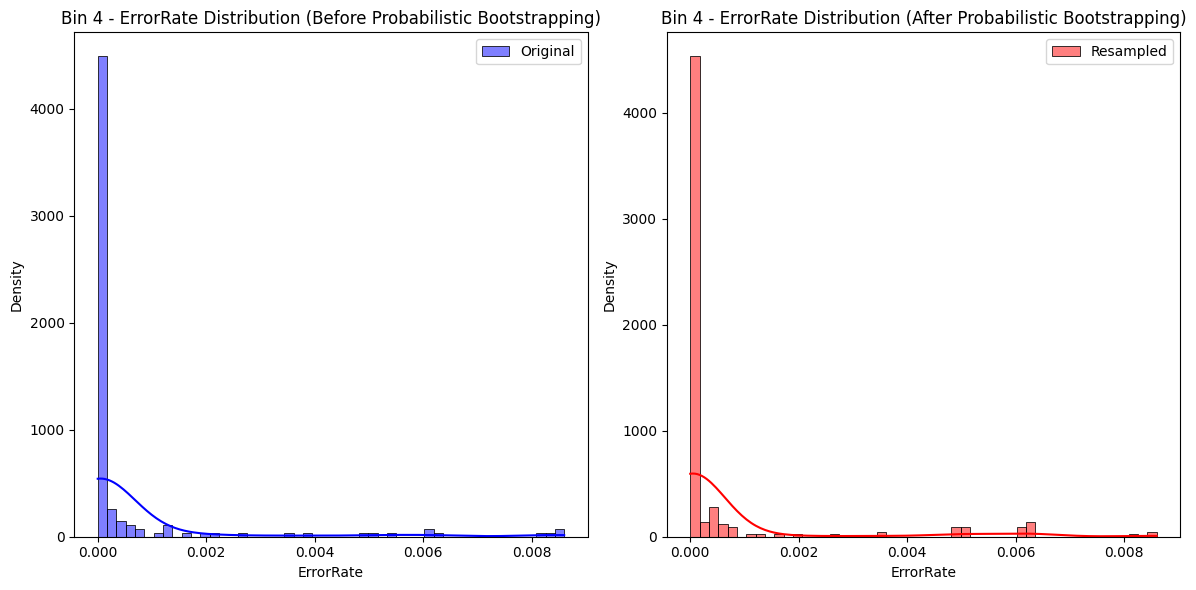

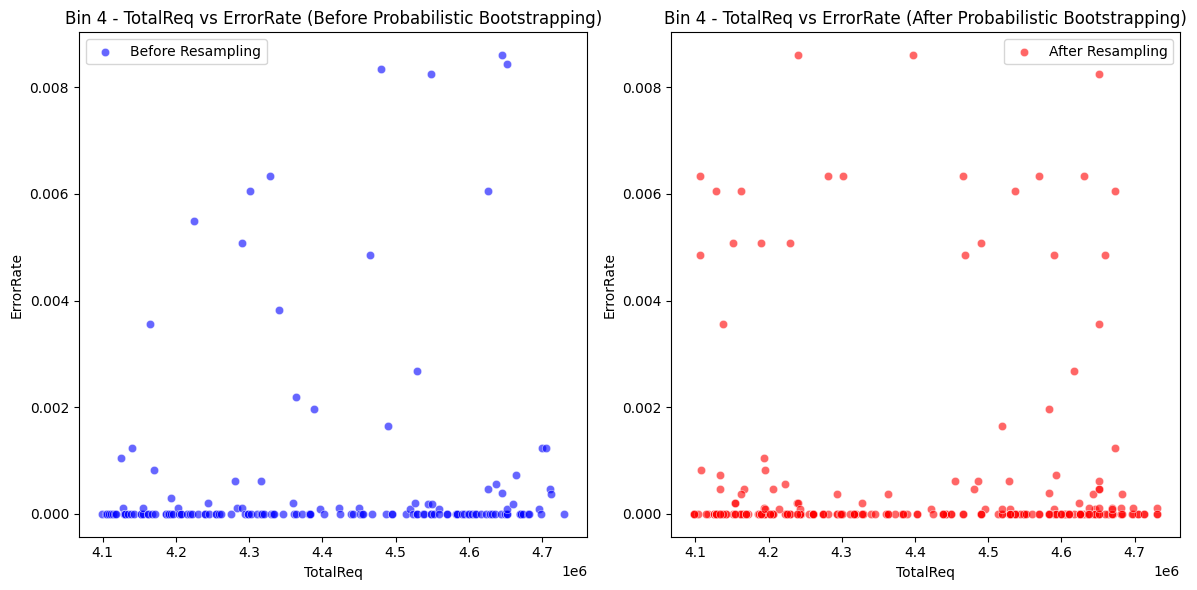

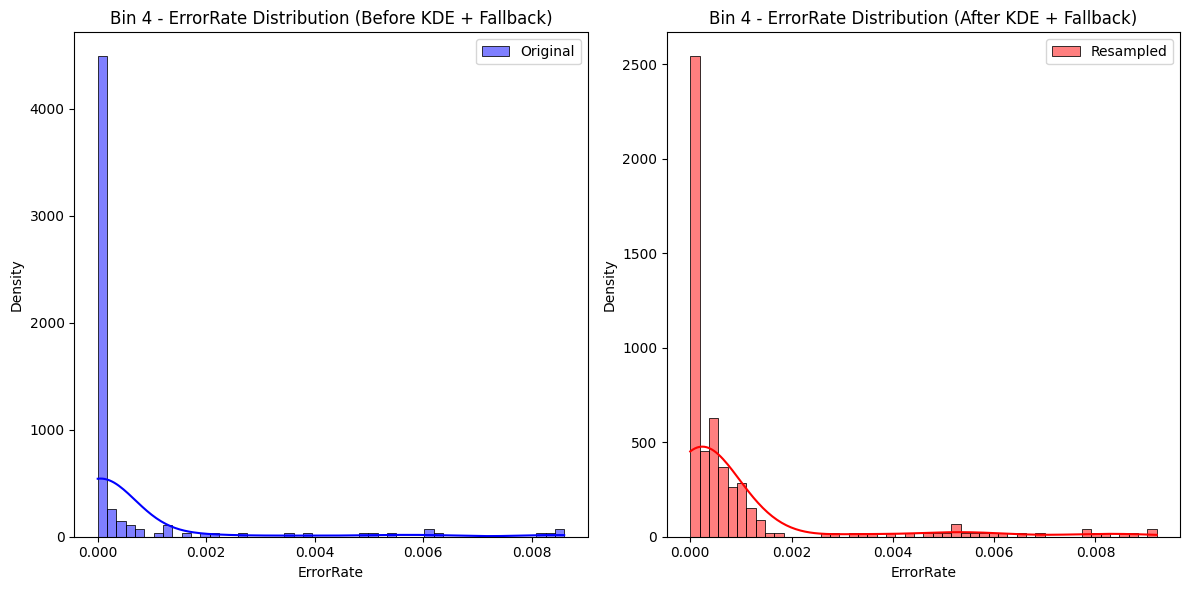

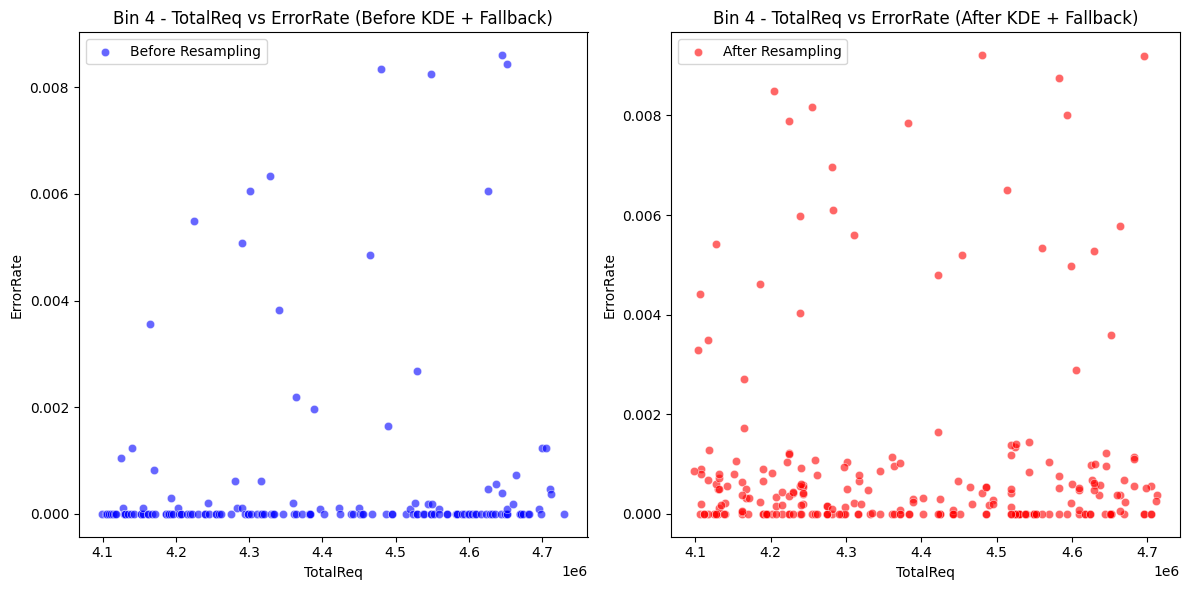

250


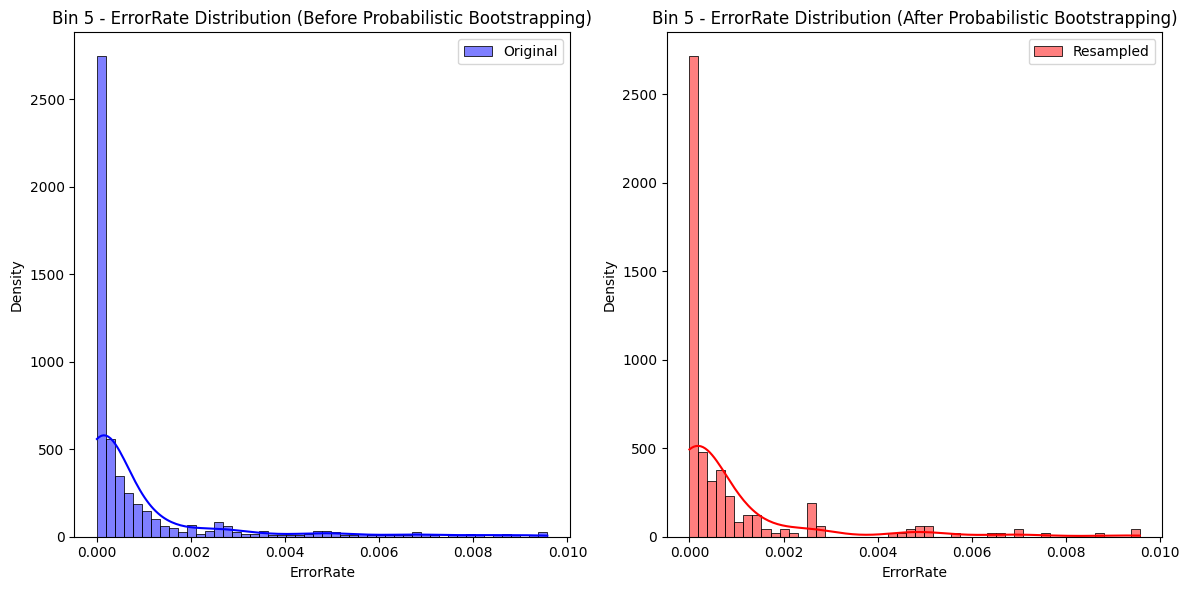

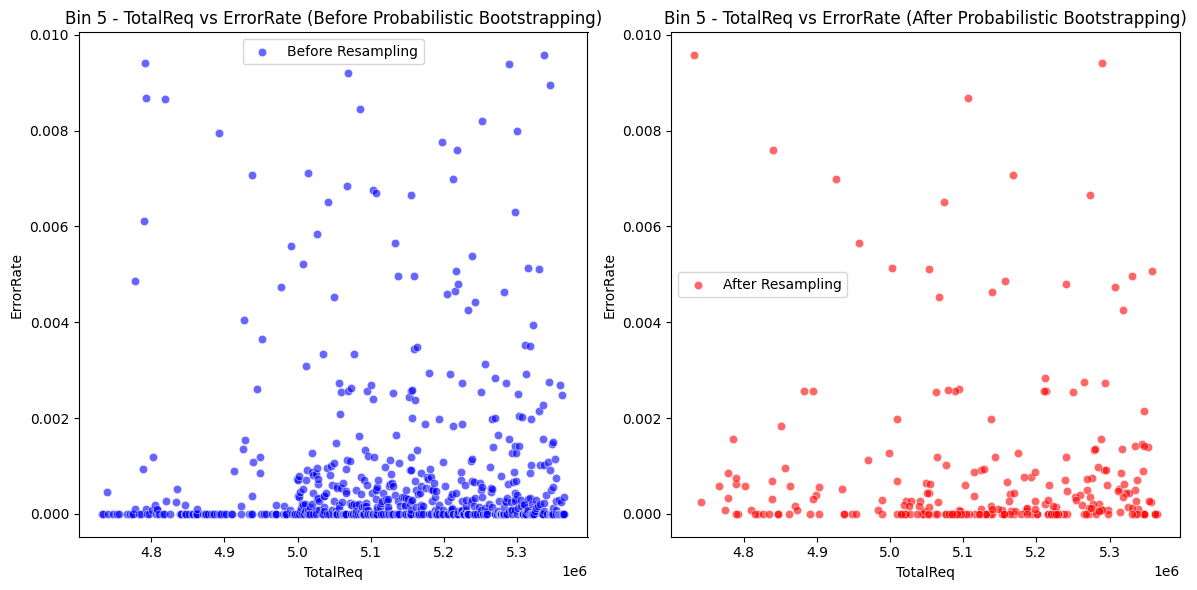

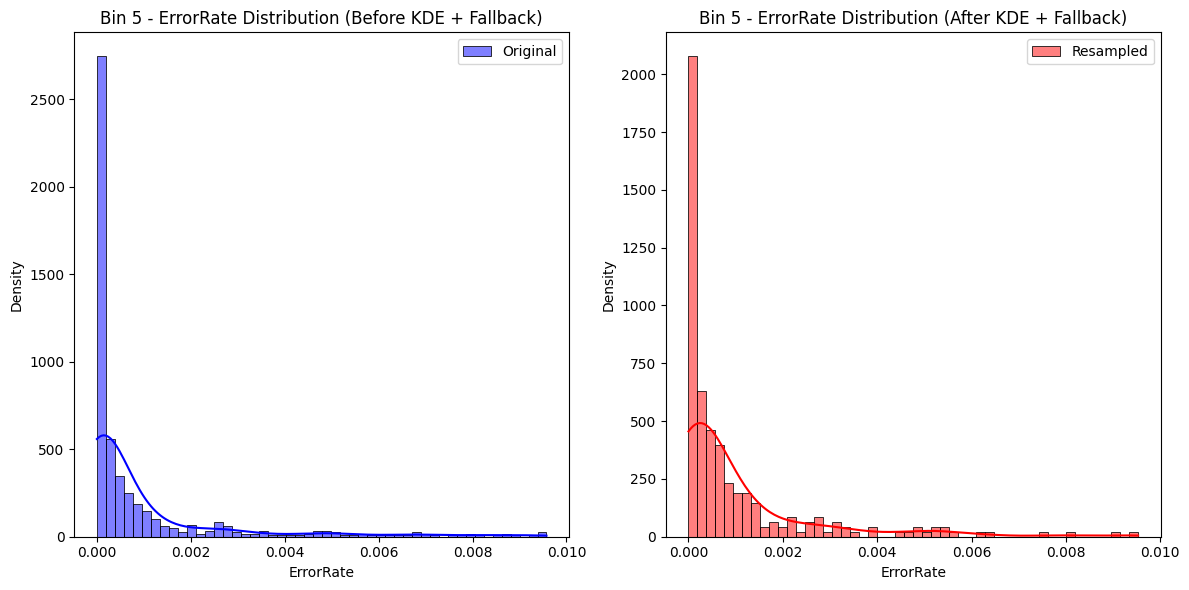

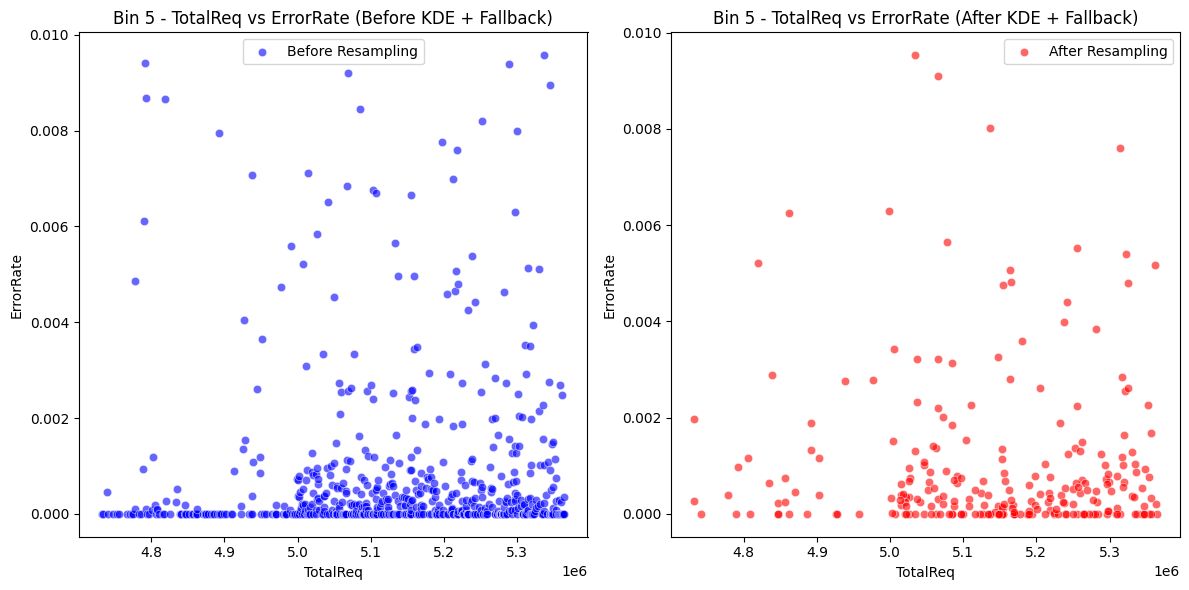

250


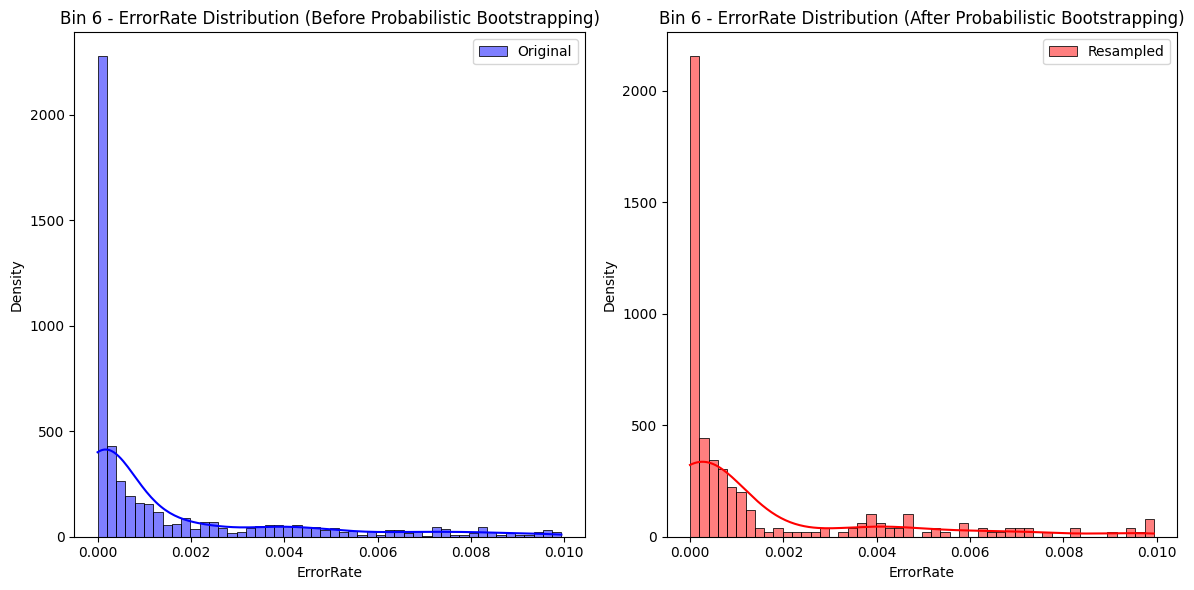

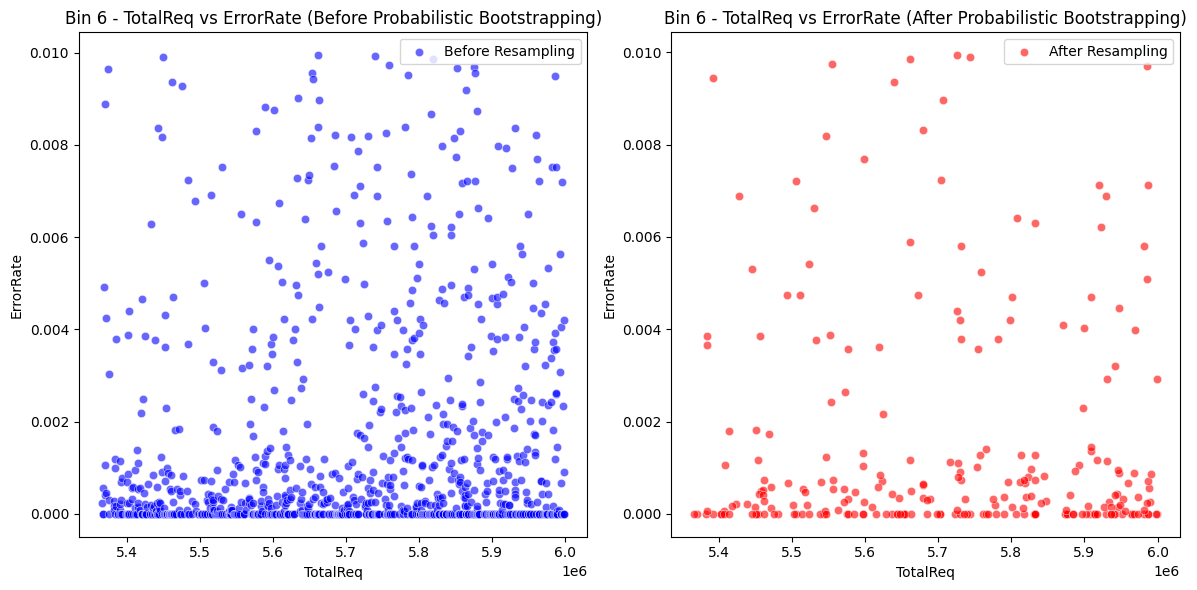

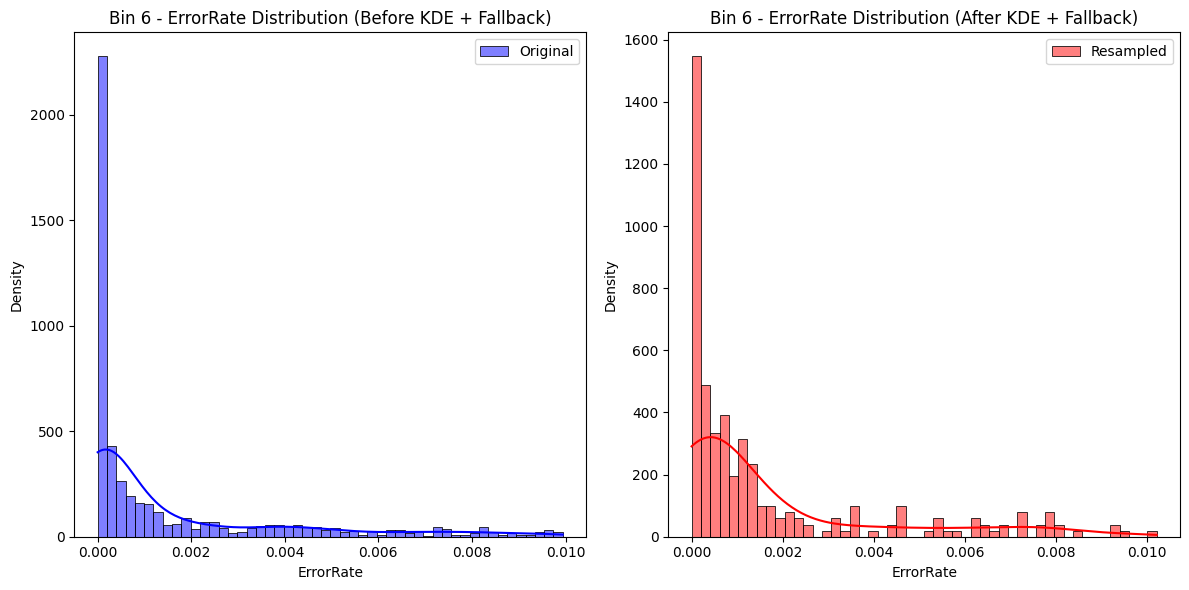

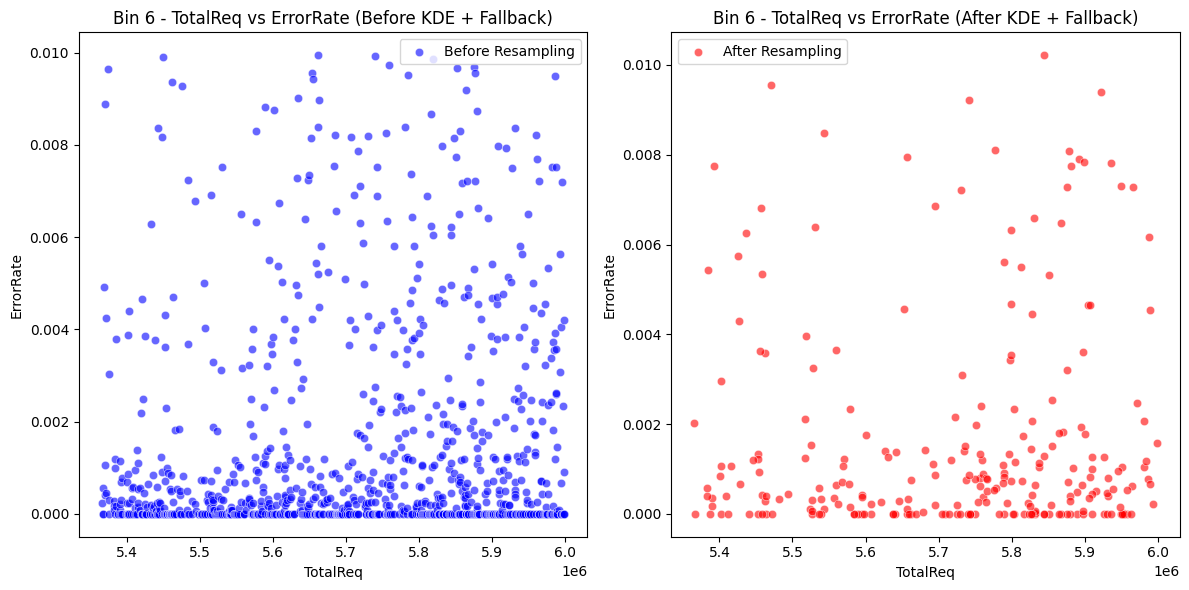

Probabilistic Bootstrapping Resampled Data:
    TotalReq  ErrorRate
0  1941300.0        0.0
1  1964440.0        0.0
2  1695365.0        0.0
3  2158341.0        0.0
4  2149835.0        0.0

KDE + Fallback Resampled Data:
    TotalReq  ErrorRate
0  1756204.0        0.0
1  1941300.0        0.0
2  2105729.0        0.0
3  1686998.0        0.0
4  2014021.0        0.0


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

df1 = pd.read_csv("error_rates.csv")
df3 = pd.read_csv("error_rates_benchkraft.csv")
df4= df1[(df1['TotalReq']>=3000000) & (df1['TotalReq']<=6000000) & (df1['ErrorRate']<=0.01)]

# Combine all dataframes
df = pd.concat([df3, df4], ignore_index=True)

# Filter out rows with TotalReq == 0 and sort the data by TotalReq
df = df[df['TotalReq'] != 0]
df = df.sort_values(by='TotalReq')

# Step 1: Filter rows with TotalReq > 1,000,000 and ErrorRate < 0.01
filtered_df = df[(df['TotalReq'] > 1000000) & (df['TotalReq'] <= 6000000)]
filtered_df = filtered_df[filtered_df['ErrorRate'] < 0.01]

# Bin 'TotalReq' into equal-width bins
bins = np.linspace(filtered_df['TotalReq'].min(), filtered_df['TotalReq'].max() + 1e-6, 8)
filtered_df['Bin'] = np.digitize(filtered_df['TotalReq'], bins) - 1

# Group by bin and collect the min, max of TotalReq and ErrorRate counts
bin_stats = filtered_df.groupby('Bin').agg(
    TotalReq_min=('TotalReq', 'min'),
    TotalReq_max=('TotalReq', 'max'),
    ErrorRate_counts=('ErrorRate', lambda x: x.value_counts().to_dict()),
    Num_Rows=('TotalReq', 'size')
).reset_index()

print(bin_stats)

# Function for probabilistic bootstrapping (with error rate probabilities)
def probabilistic_bootstrap(bin_df, target_size):
    error_rate_values = bin_df['ErrorRate'].values
    
    # Compute probabilities based on frequency of error rates
    error_rate_counts = pd.Series(error_rate_values).value_counts(normalize=True) 
    unique_error_rates = error_rate_counts.index.values  # Unique error rates
    probabilities = error_rate_counts.values  # Corresponding probabilities
    
    # Resample error rates using the computed probabilities
    new_error_rates = np.random.choice(unique_error_rates, size=target_size, p=probabilities)
    
    # Resample TotalReq values randomly
    total_req_values = bin_df['TotalReq'].values
    new_totalreq = np.random.choice(total_req_values, size=target_size)
    
    # Create a new DataFrame with the resampled ErrorRates and TotalReq values
    resampled_df = pd.DataFrame({
        'TotalReq': new_totalreq,
        'ErrorRate': new_error_rates.flatten()
    })
    
    return resampled_df

# Function for KDE resampling (with fallback to probabilistic bootstrapping)
def kde_resample(bin_df, target_size):
    error_rate_values = bin_df['ErrorRate'].values
    
    # Check if there are enough distinct ErrorRate values
    if len(np.unique(error_rate_values)) < 2:
        print(f"Not enough distinct ErrorRate values in bin {bin_df['Bin'].iloc[0]}. Falling back to probabilistic bootstrapping.")
        
        # Probabilistic bootstrapping: Compute probabilities based on frequency
        error_rate_counts = pd.Series(error_rate_values).value_counts(normalize=True) 
        unique_error_rates = error_rate_counts.index.values  # Unique error rates
        probabilities = error_rate_counts.values  # Corresponding probabilities
        
        # Resample using the computed probabilities
        new_error_rates = np.random.choice(unique_error_rates, size=target_size, p=probabilities)
    else:
        try:
            # Try KDE resampling
            kde = gaussian_kde(error_rate_values, bw_method='scott')
            new_error_rates = kde.resample(target_size)  
            
            # Clip the error rates to ensure they are within [0, 1]
            new_error_rates = np.clip(new_error_rates, 0, 1)
        except np.linalg.LinAlgError:
            # If KDE fails, fallback to probabilistic bootstrapping
            print(f"KDE failed for bin {bin_df['Bin'].iloc[0]}. Falling back to probabilistic bootstrapping.")
            new_error_rates = np.random.choice(unique_error_rates, size=target_size, p=probabilities)
    
    # Resample TotalReq values randomly
    total_req_values = bin_df['TotalReq'].values
    new_totalreq = np.random.choice(total_req_values, size=target_size)
    
    # Create a new DataFrame with the resampled ErrorRates and TotalReq values
    resampled_df = pd.DataFrame({
        'TotalReq': new_totalreq,
        'ErrorRate': new_error_rates.flatten()  
    })
    
    return resampled_df

# Function for plotting the distribution of error rates before and after resampling for each bin
def plot_error_rate_distribution(bin_df, resampled_bin_df, bin_id, approach):
    plt.figure(figsize=(12, 6))
    
    # Plot before resampling
    plt.subplot(1, 2, 1)
    sns.histplot(bin_df['ErrorRate'], bins=50, kde=True, color='blue', label='Original', stat='density')
    plt.title(f'Bin {bin_id} - ErrorRate Distribution (Before {approach})')
    plt.xlabel('ErrorRate')
    plt.ylabel('Density')
    plt.legend()
    
    # Plot after resampling
    plt.subplot(1, 2, 2)
    sns.histplot(resampled_bin_df['ErrorRate'], bins=50, kde=True, color='red', label='Resampled', stat='density')
    plt.title(f'Bin {bin_id} - ErrorRate Distribution (After {approach})')
    plt.xlabel('ErrorRate')
    plt.ylabel('Density')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Function to plot TotalReq vs ErrorRate before and after resampling for each bin
def plot_totalreq_vs_errorrate(bin_df, resampled_bin_df, bin_id, approach):
    plt.figure(figsize=(12, 6))
    
    # Plot before resampling
    plt.subplot(1, 2, 1)
    sns.scatterplot(data=bin_df, x='TotalReq', y='ErrorRate', color='blue', alpha=0.6, label='Before Resampling')
    plt.title(f'Bin {bin_id} - TotalReq vs ErrorRate (Before {approach})')
    plt.xlabel('TotalReq')
    plt.ylabel('ErrorRate')
    
    # Plot after resampling
    plt.subplot(1, 2, 2)
    sns.scatterplot(data=resampled_bin_df, x='TotalReq', y='ErrorRate', color='red', alpha=0.6, label='After Resampling')
    plt.title(f'Bin {bin_id} - TotalReq vs ErrorRate (After {approach})')
    plt.xlabel('TotalReq')
    plt.ylabel('ErrorRate')
    
    plt.tight_layout()
    plt.show()

# Create an empty DataFrame to store all resampled data (for both bootstrapping and kde fallback)
all_prob_bootstrapped_data = []
all_kde_resampled_data = []

# Loop through each bin, apply resampling, and plot the results
for bin_id in bin_stats['Bin']:
    # Original data for this bin
    bin_df = filtered_df[filtered_df['Bin'] == bin_id]
    
    # Perform probabilistic bootstrapping for this bin
    target_size = 250
    print(target_size)# Desired number of rows after resampling
    prob_bootstrap_bin = probabilistic_bootstrap(bin_df, target_size)
    
    # Perform KDE + fallback resampling for this bin
    kde_bin = kde_resample(bin_df, target_size)
    
    # Append the resampled data to the lists
    all_prob_bootstrapped_data.append(prob_bootstrap_bin)
    all_kde_resampled_data.append(kde_bin)
    
    # Plot before and after resampling for the bin (probabilistic bootstrapping)
    plot_error_rate_distribution(bin_df, prob_bootstrap_bin, bin_id, 'Probabilistic Bootstrapping')
    plot_totalreq_vs_errorrate(bin_df, prob_bootstrap_bin, bin_id, 'Probabilistic Bootstrapping')
    
    # Plot before and after resampling for the bin (KDE + Fallback)
    plot_error_rate_distribution(bin_df, kde_bin, bin_id, 'KDE + Fallback')
    plot_totalreq_vs_errorrate(bin_df, kde_bin, bin_id, 'KDE + Fallback')

# Concatenate all the resampled data into two DataFrames (for both approaches)
df_prob_bootstrapped = pd.concat(all_prob_bootstrapped_data, ignore_index=True)
df_kde_resampled = pd.concat(all_kde_resampled_data, ignore_index=True)

# Display the final resampled DataFrames
print("Probabilistic Bootstrapping Resampled Data:")
print(df_prob_bootstrapped.head())

print("\nKDE + Fallback Resampled Data:")
print(df_kde_resampled.head())

In [2]:
import plotly.express as px


# Create a scatter plot
fig = px.scatter(df_kde_resampled, x='TotalReq', y='ErrorRate', 
                 title='Scatter Plot of TotalReq vs ErrorRate', 
                 labels={'TotalReq': 'X-Axis: TotalReq', 'ErrorRate': 'Y-Axis: ErrorRate'})

# Show plot
fig.show()

In [3]:
import plotly.express as px


# Create a scatter plot
fig = px.scatter(df_prob_bootstrapped, x='TotalReq', y='ErrorRate', 
                 title='Scatter Plot of TotalReq vs ErrorRate', 
                 labels={'TotalReq': 'X-Axis: TotalReq', 'ErrorRate': 'Y-Axis: ErrorRate'})

# Show plot
fig.show()

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

df = pd.DataFrame(df_kde_resampled)
df = df.sort_values(by='TotalReq')

# 1. Binning the 'error_rates' and 'TotalReq' columns into numeric intervals
error_rate_bins = pd.cut(df['ErrorRate'], bins=7, labels= False)
total_req_bins = pd.cut(df['TotalReq'], bins=7, labels= False)
df['error_rate_bin'] = error_rate_bins
df['total_req_bin'] = total_req_bins

# 2. Create a contingency table to analyze the relationship
contingency_table = pd.crosstab(df['error_rate_bin'], df['total_req_bin'])

# 3. Normalize the contingency table based on each column's sum
contingency_percentage_column_normalized = contingency_table.div(contingency_table.sum(axis=0), axis=1) * 100

# Display the contingency table with percentages (column-normalized)
print("Contingency Table with Percentages (Column Normalized):")
print(contingency_percentage_column_normalized)

# 4. Calculate the Chi-Square statistic to see if there's a significant relationship
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Display the results of the Chi-Square test
print("\nChi-Square Test Results:")
print(f"Chi-Square Statistic: {chi2}")
print(f"P-Value: {p}")
print(f"Degrees of Freedom: {dof}")

# Optional: You can also check the expected frequencies to see how they compare to the observed ones.
print("\nExpected Frequencies:")
print(expected)


Contingency Table with Percentages (Column Normalized):
total_req_bin       0      1      2     3     4          5          6
error_rate_bin                                                       
0               100.0  100.0  100.0  97.6  88.0  81.124498  72.111554
1                 0.0    0.0    0.0   0.0   1.6   9.236948   8.366534
2                 0.0    0.0    0.0   0.4   1.6   3.212851   4.780876
3                 0.0    0.0    0.0   0.0   4.0   4.016064   4.780876
4                 0.0    0.0    0.0   0.0   1.6   0.803213   4.382470
5                 0.0    0.0    0.0   2.0   2.4   0.803213   3.984064
6                 0.0    0.0    0.0   0.0   0.8   0.803213   1.593625

Chi-Square Test Results:
Chi-Square Statistic: 278.4533927720476
P-Value: 3.040183385634988e-39
Degrees of Freedom: 36

Expected Frequencies:
[[228.14285714 228.14285714 228.14285714 228.14285714 228.14285714
  227.23028571 229.05542857]
 [  6.85714286   6.85714286   6.85714286   6.85714286   6.85714286
    6.82

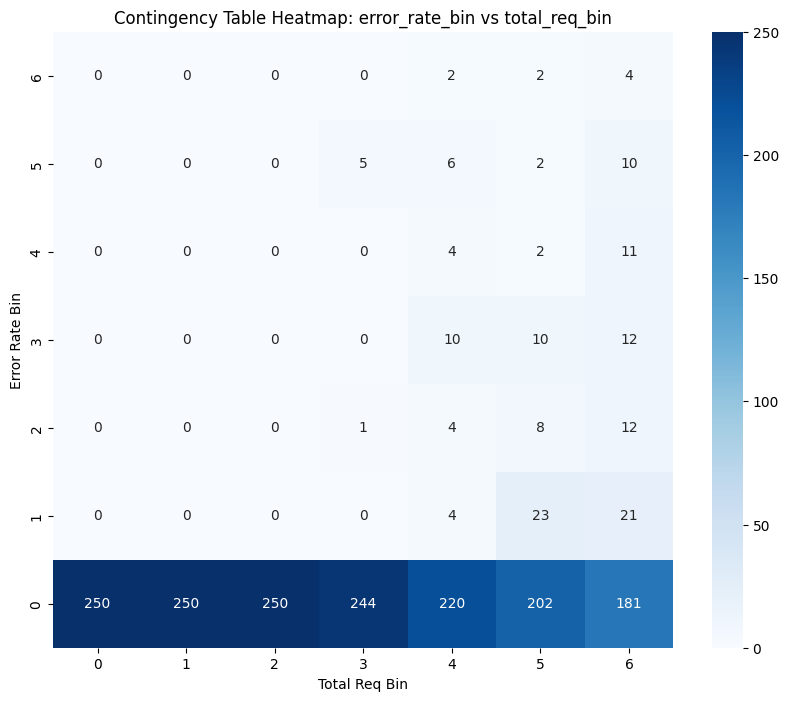

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting a heatmap of the contingency table
plt.figure(figsize=(10, 8))
sns.heatmap(contingency_table, annot=True, cmap="Blues", fmt="d")
plt.gca().invert_yaxis()
plt.title("Contingency Table Heatmap: error_rate_bin vs total_req_bin")
plt.ylabel("Error Rate Bin")
plt.xlabel("Total Req Bin")
plt.show()

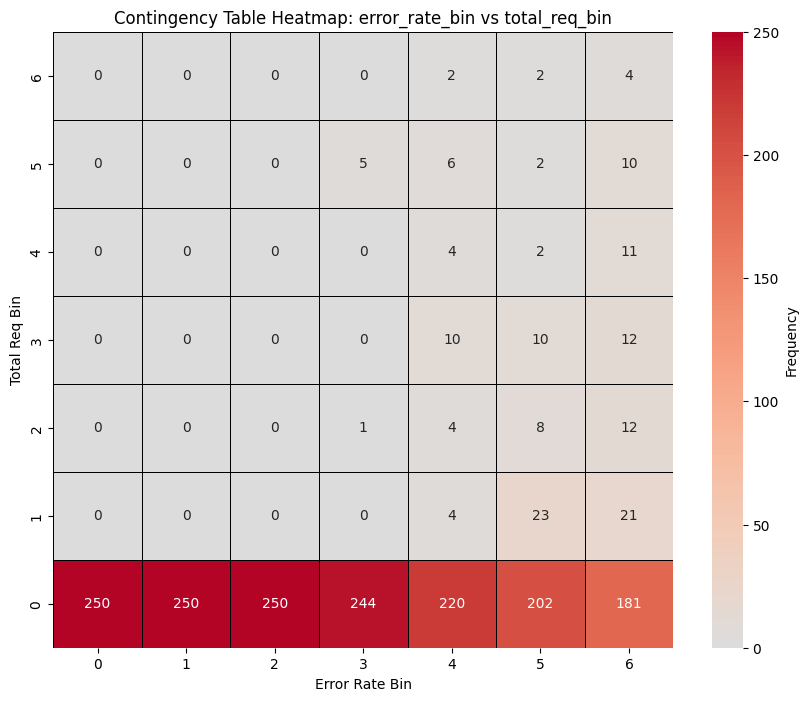

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Assuming df is your DataFrame and it is already prepared
# Create the contingency table based on error_rate_bin and total_req_bin (already given)
# Assuming you have a contingency table 'contingency_table'

# Define a custom color map function for both error_rate_bin and values
def custom_color(value, error_rate_bin):
    """ Custom color logic for each cell in the contingency table. """
    max_value = np.max(contingency_table.values)  # Get the max value for normalization
    
    if error_rate_bin == 0:  # For the 0th bin (low error rate), use blue intensities
        return plt.cm.Blues(value / max_value)  # Scale intensity of blue with value
    elif error_rate_bin >= 1:  # For higher error rate bins, use red intensities
        return plt.cm.Reds(value / max_value)  # Scale intensity of red with value

# Apply the custom colormap to each cell in the contingency table
def apply_custom_colors(contingency_table):
    # Create a matrix of colors based on the custom logic
    colors = np.empty(contingency_table.shape, dtype=object)
    for i in range(contingency_table.shape[0]):  # Iterate over rows (error_rate_bin)
        for j in range(contingency_table.shape[1]):  # Iterate over columns (total_req_bin)
            colors[i, j] = custom_color(contingency_table.iloc[i, j], i)  # Apply custom color
    return colors

# Apply the custom colormap to the contingency table
colored_cells = apply_custom_colors(contingency_table)

# Plotting the heatmap with custom colors
plt.figure(figsize=(10, 8))

# Heatmap using the custom colors for each cell
sns.heatmap(
    contingency_table, 
    annot=True, 
    fmt="d", 
    cmap="coolwarm",  # Placeholder, but will use custom colors instead
    cbar_kws={'label': 'Frequency'},
    linewidths=0.5,
    center=0,  # This is to center the color scale for better visualization
    linecolor='black'  # Adding a gridline for better visibility
)

# Reverse the y-axis to have total_req_bin bins at the bottom
plt.gca().invert_yaxis()

# Set the labels and title
plt.title("Contingency Table Heatmap: error_rate_bin vs total_req_bin")
plt.ylabel("Total Req Bin")  # Now total_req_bin is on the y-axis
plt.xlabel("Error Rate Bin")

# Show the plot
plt.show()


Contingency Table with Percentages (Column Normalized):
total_req_bin       0      1      2     3     4          5          6
error_rate_bin                                                       
0               100.0  100.0  100.0  97.6  88.0  81.124498  72.111554
1                 0.0    0.0    0.0   0.0   1.6   9.236948   8.366534
2                 0.0    0.0    0.0   0.4   1.6   3.212851   4.780876
3                 0.0    0.0    0.0   0.0   4.0   4.016064   4.780876
4                 0.0    0.0    0.0   0.0   1.6   0.803213   4.382470
5                 0.0    0.0    0.0   2.0   2.4   0.803213   3.984064
6                 0.0    0.0    0.0   0.0   0.8   0.803213   1.593625

Chi-Square Test Results:
Chi-Square Statistic: 278.4533927720476
P-Value: 3.040183385634988e-39
Degrees of Freedom: 36

Expected Frequencies:
[[228.14285714 228.14285714 228.14285714 228.14285714 228.14285714
  227.23028571 229.05542857]
 [  6.85714286   6.85714286   6.85714286   6.85714286   6.85714286
    6.82

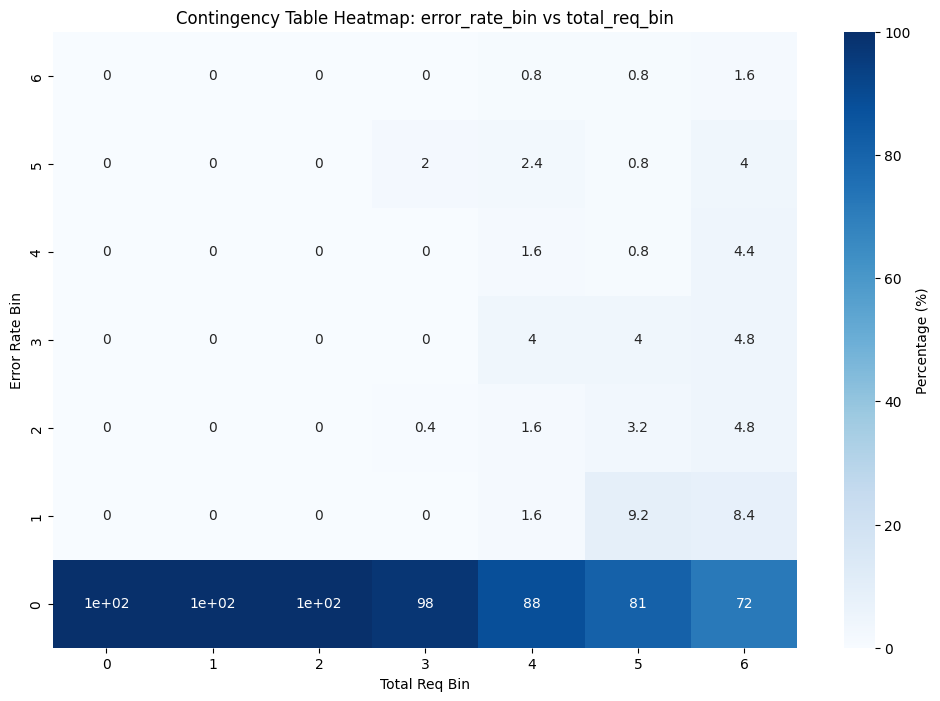

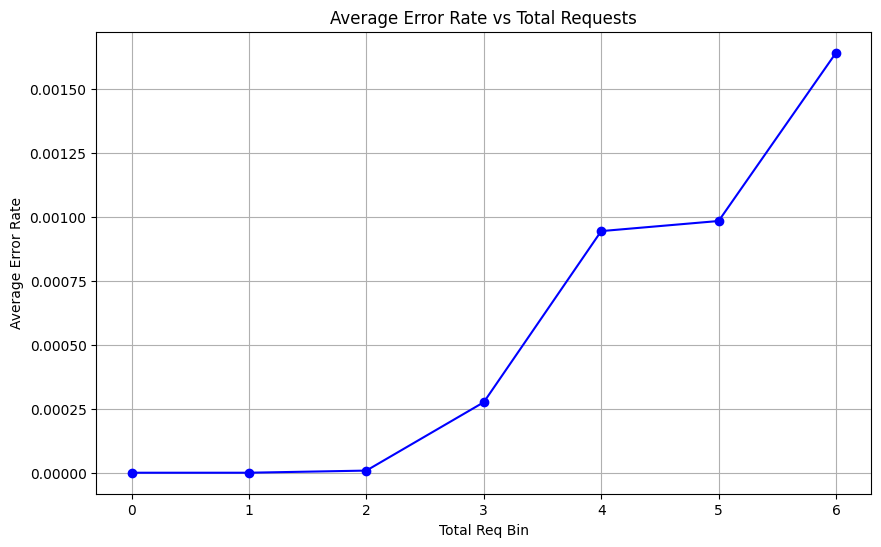

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

df = pd.DataFrame(df_kde_resampled)

# Sort by 'TotalReq' 
df = df.sort_values(by='TotalReq')

# Binning the 'ErrorRate' and 'TotalReq' columns 
error_rate_bins = pd.cut(df['ErrorRate'], bins=7, labels=False)
total_req_bins = pd.cut(df['TotalReq'], bins=7, labels=False)
df['error_rate_bin'] = error_rate_bins
df['total_req_bin'] = total_req_bins

# Create a contingency table (counts of occurrences in each bin combination)
contingency_table = pd.crosstab(df['error_rate_bin'], df['total_req_bin'])

# Normalize the contingency table by column 
contingency_percentage_column_normalized = contingency_table.div(contingency_table.sum(axis=0), axis=1) * 100

print("Contingency Table with Percentages (Column Normalized):")
print(contingency_percentage_column_normalized)

# Calculate the Chi-Square statistic
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Test Results:")
print(f"Chi-Square Statistic: {chi2}")
print(f"P-Value: {p}")
print(f"Degrees of Freedom: {dof}")
print("\nExpected Frequencies:")
print(expected)

# Heatmap to show the relationship between error_rate_bin and total_req_bin
plt.figure(figsize=(12, 8))
sns.heatmap(contingency_percentage_column_normalized, annot=True, cmap="Blues",  cbar_kws={'label': 'Percentage (%)'})
plt.gca().invert_yaxis()
plt.title("Contingency Table Heatmap: error_rate_bin vs total_req_bin")
plt.xlabel("Total Req Bin")
plt.ylabel("Error Rate Bin")
plt.show()

# 5. PLot the average error rate in each TotalReq bin
avg_error_rate_per_bin = df.groupby('total_req_bin')['ErrorRate'].mean()

plt.figure(figsize=(10, 6))
avg_error_rate_per_bin.plot(kind='line', marker='o', color='b')
plt.title("Average Error Rate vs Total Requests")
plt.xlabel("Total Req Bin")
plt.ylabel("Average Error Rate")
plt.grid(True)
plt.show()


/tmp/ipykernel_2918671/3996922554.py:24: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




/tmp/ipykernel_2918671/3996922554.py:53: UserWarning:

FixedFormatter should only be used together with FixedLocator

/tmp/ipykernel_2918671/3996922554.py:54: UserWarning:

FixedFormatter should only be used together with FixedLocator



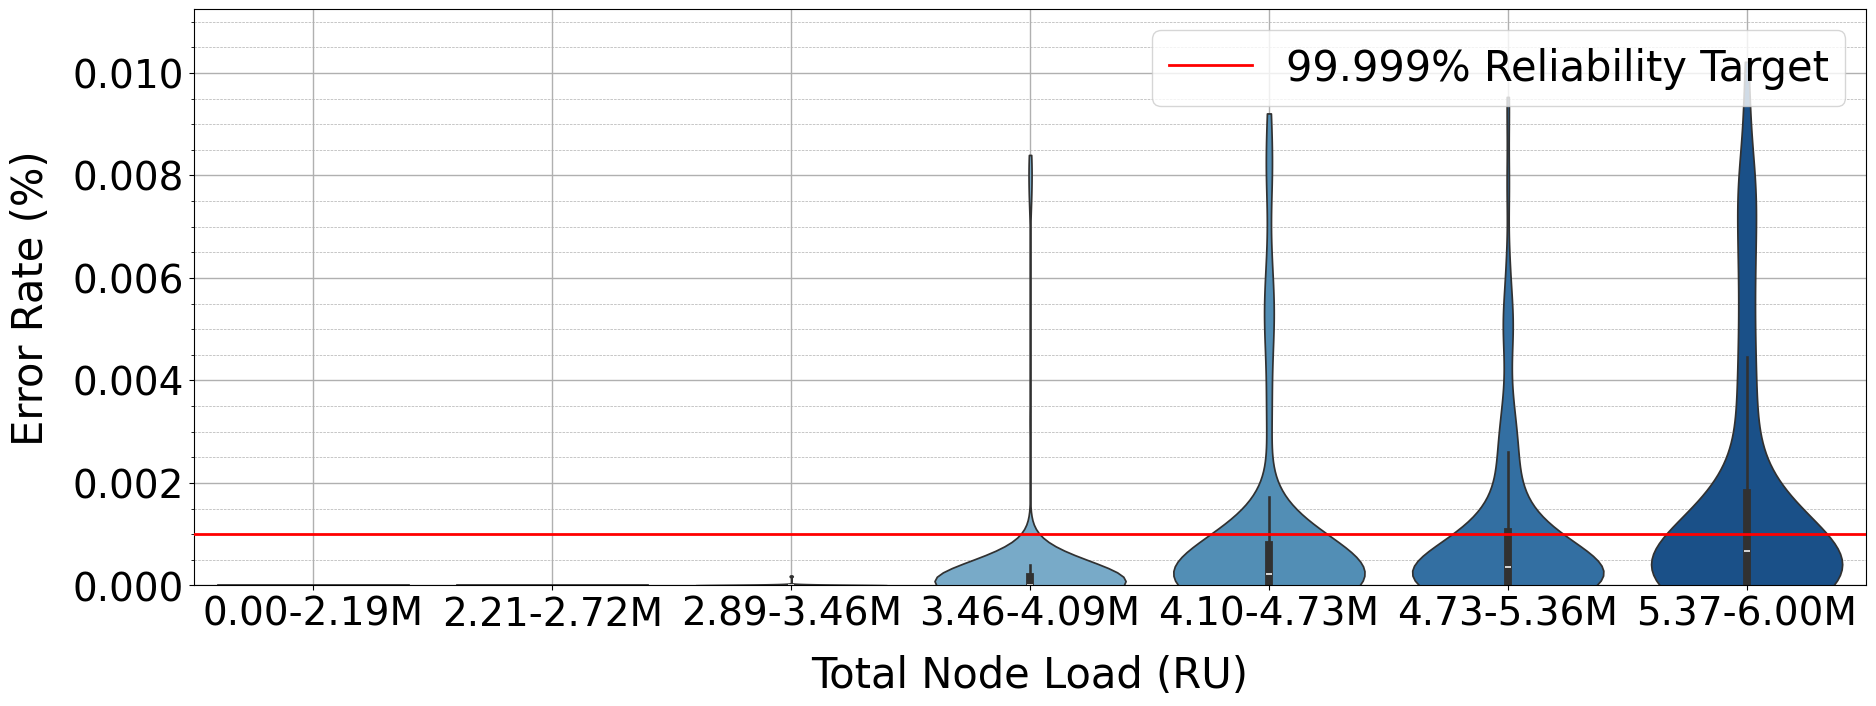

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

# Format bin labels to show RU values in millions with 2 decimal places
bin_labels = {
    0: "0.00-2.19M",
    1: "2.21-2.72M",
    2: "2.89-3.46M", 
    3: "3.46-4.09M",
    4: "4.10-4.73M",
    5: "4.73-5.36M",
    6: "5.37-6.00M"
}

# Map the bin numbers to their respective range labels
df['total_req_bin_label'] = df['total_req_bin'].map(bin_labels)

# Create a figure with more horizontal space
fig, ax = plt.subplots(figsize=(22, 8))  # Wider figure to fit numbers better

# Plot violin plot FIRST with high z-order
sns.violinplot(x='total_req_bin_label', y='ErrorRate', data=df, palette='Blues', ax=ax, cut=0, zorder=2)

# Now set grid lines (zorder=0 to ensure they are behind the violins)
ax.grid(axis='y', which='major', linestyle='-', linewidth=1, zorder=0)
ax.grid(axis='y', which='minor', linestyle='--', linewidth=0.5, zorder=0)
ax.grid(axis='x', which='major', linestyle='-', linewidth=1, zorder=0)

# Increase space occupied by numbers (tick labels & axis labels)
ax.set_xlabel("Total Node Load (RU)", fontsize=30, labelpad=15)  # Bigger font & spacing
ax.set_ylabel("Error Rate (%)", fontsize=30, labelpad=15)  # Bigger font & spacing
ax.tick_params(axis='both', which='major', labelsize=18)  # Bigger tick labels

# Adjust y-axis range to occupy more space
ax.set_ylim(bottom=0, top=max(df['ErrorRate']) * 1.1)  # Ensure numbers fit well

# Enable minor ticks for y-axis with steps of 0.0005
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.0005))

# Format y-axis to display 3 decimal places without % symbol
def decimal_formatter(x, pos):
    return f'{x:.3f}'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(decimal_formatter))

# Add red horizontal line at 0.001 (99.999% reliability target) with highest z-order
ax.axhline(y=0.001, color='red', linestyle='-', linewidth=2, label='99.999% Reliability Target', zorder=3)

# Add legend inside the plot with a font size equal to the caption size
ax.legend(loc='upper right', fontsize=30, frameon=True)  # Bigger legend text
ax.set_xticklabels(ax.get_xticklabels(), fontsize=28, rotation=0)  # Slight rotation for better spacing
ax.set_yticklabels(ax.get_yticklabels(), fontsize=28, rotation=0)
# Reduce unnecessary margins & white space
plt.subplots_adjust(left=0.14, right=0.9, top=0.9, bottom=0.18)  # More space for numbers

# Save as PDF with tight bounding box to maximize space usage
plt.savefig('error_rate_vs_node_load.png', format='png', dpi=400, bbox_inches='tight')

# Show the plot
plt.show()


/tmp/ipykernel_2918671/989718114.py:24: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




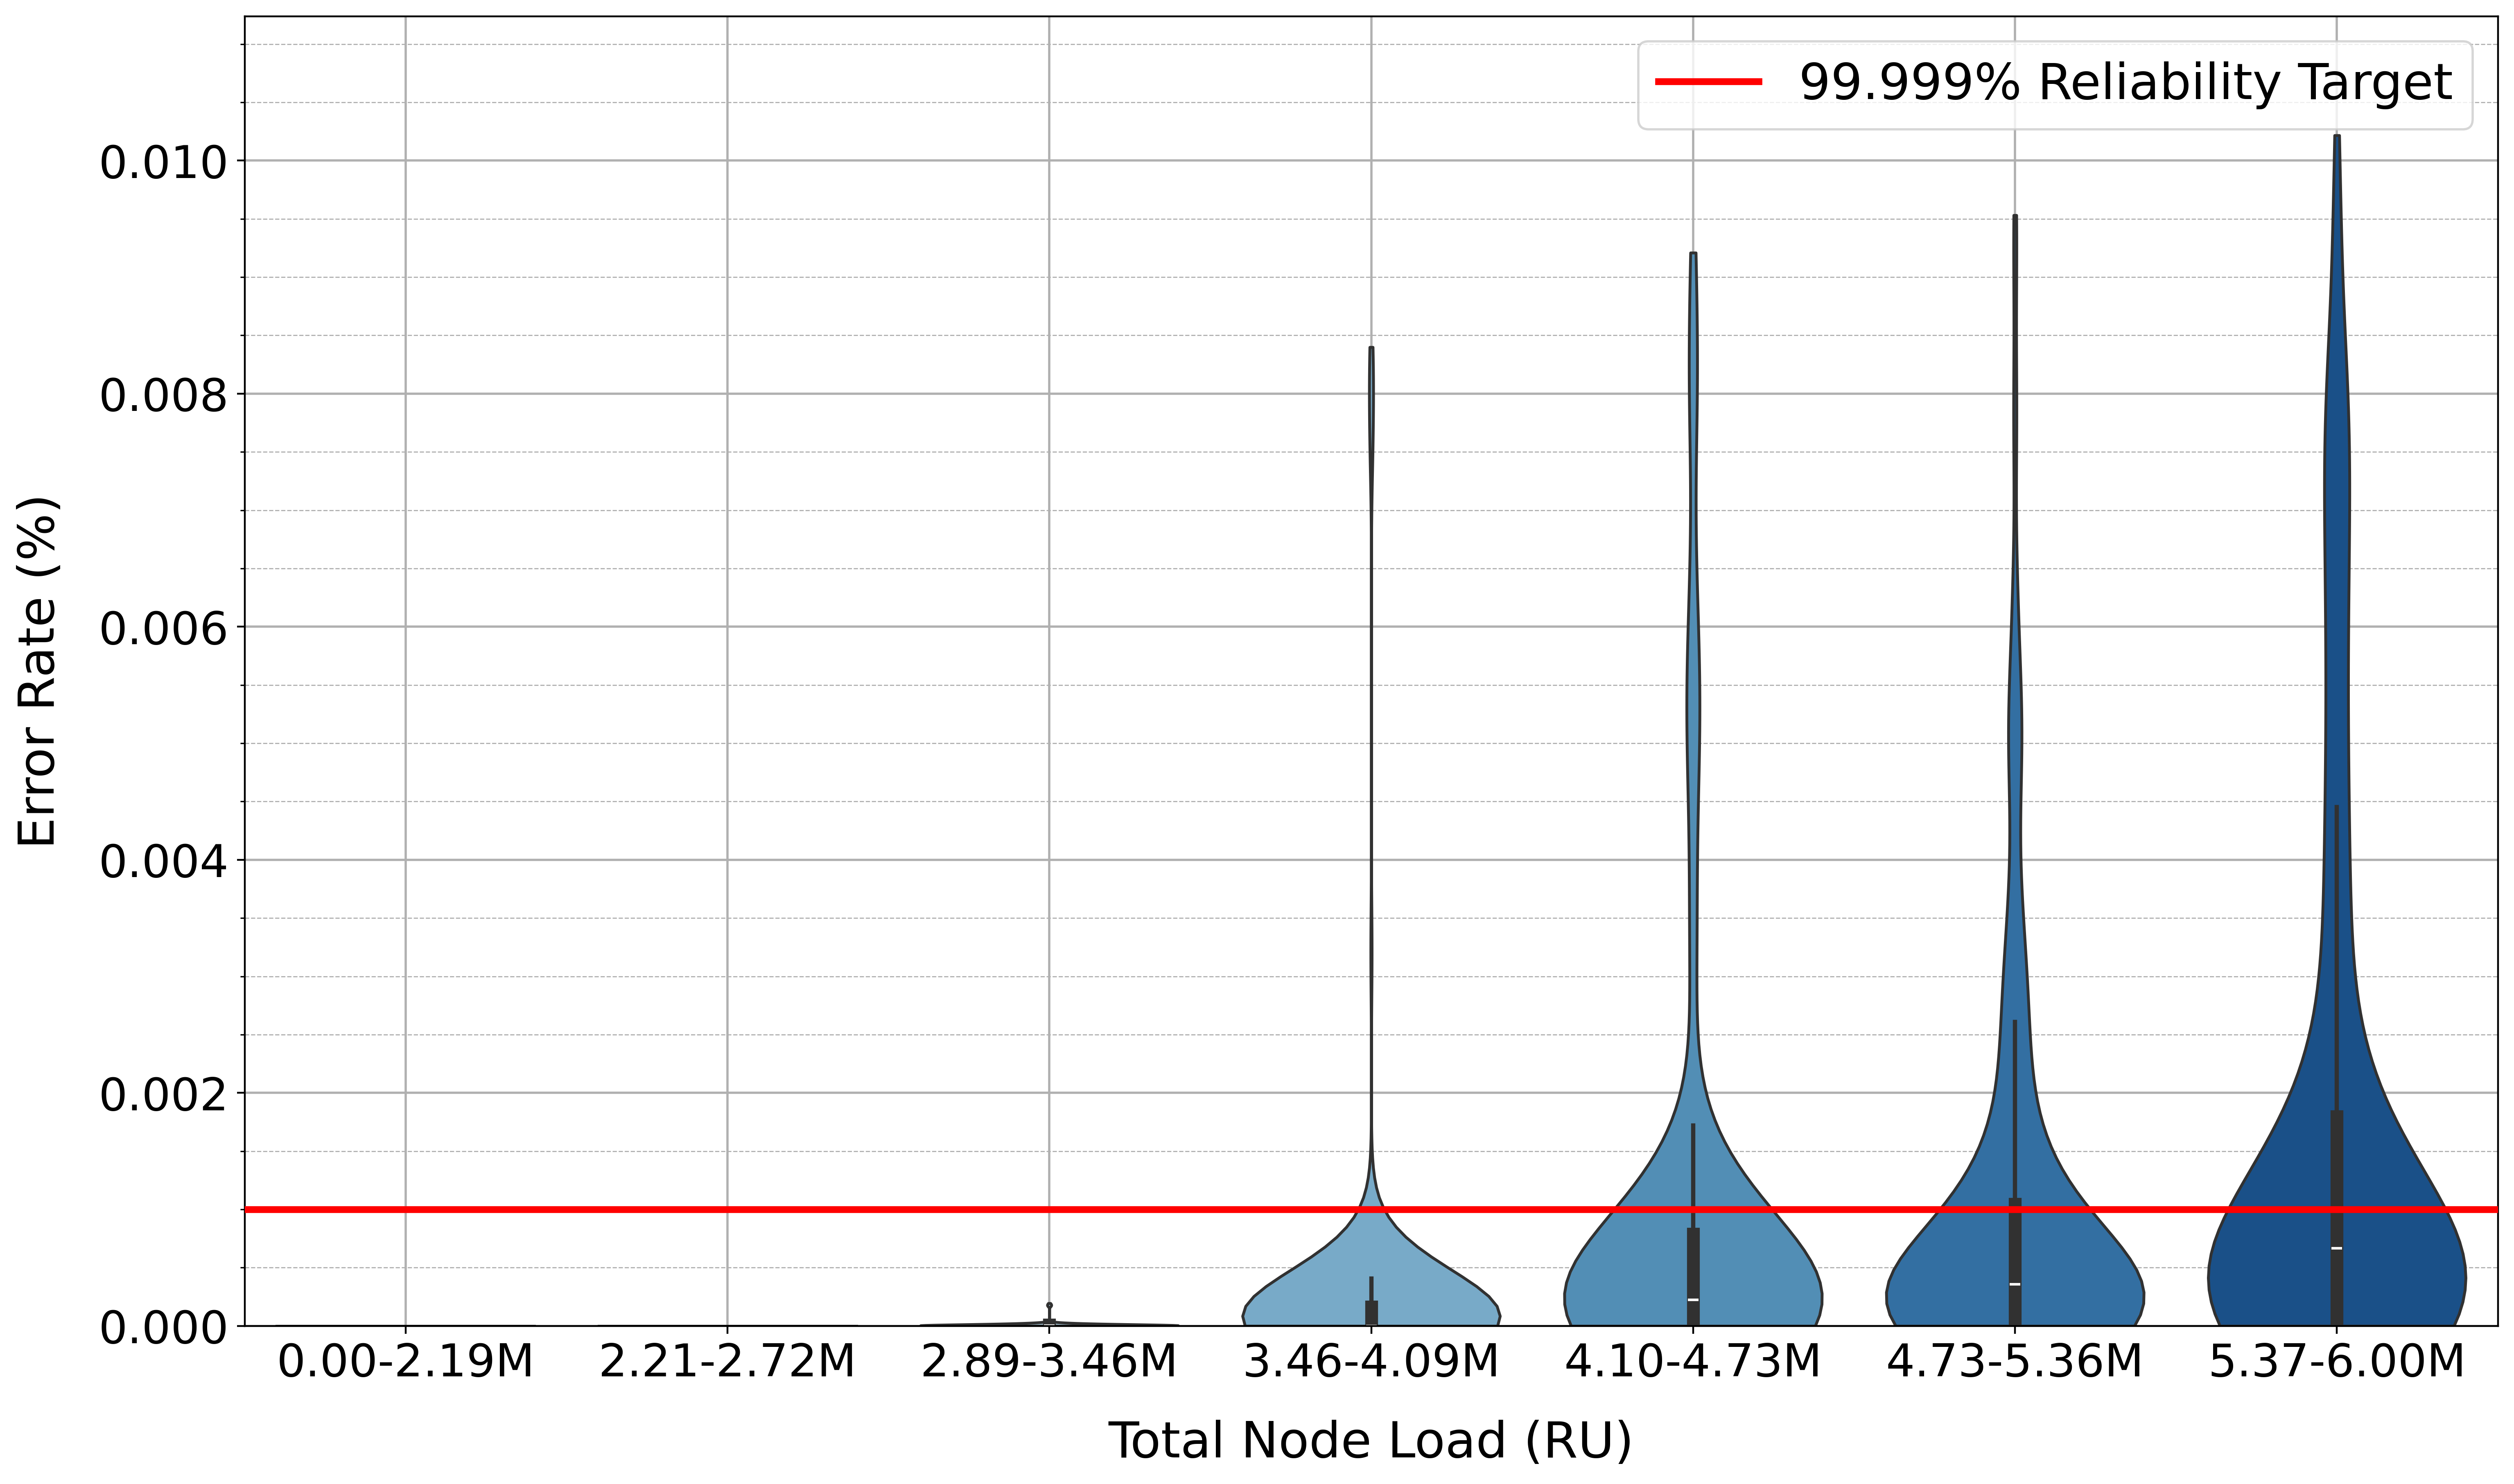

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

# Format bin labels to show RU values in millions with 2 decimal places
bin_labels = {
    0: "0.00-2.19M",
    1: "2.21-2.72M",
    2: "2.89-3.46M", 
    3: "3.46-4.09M",
    4: "4.10-4.73M",
    5: "4.73-5.36M",
    6: "5.37-6.00M"
}

# Map the bin numbers to their respective range labels
df['total_req_bin_label'] = df['total_req_bin'].map(bin_labels)

# Create a larger figure for better spacing
fig, ax = plt.subplots(figsize=(16, 10), dpi=400)  # Increased DPI for better quality

# Plot violin plot FIRST with high z-order
sns.violinplot(x='total_req_bin_label', y='ErrorRate', data=df, palette='Blues', ax=ax, cut=0, zorder=2)

# Now set grid lines (zorder=0 to ensure they are behind the violins)
ax.grid(axis='y', which='major', linestyle='-', linewidth=1, zorder=0)
ax.grid(axis='y', which='minor', linestyle='--', linewidth=0.5, zorder=0)
ax.grid(axis='x', which='major', linestyle='-', linewidth=1, zorder=0)

# Increase font sizes for better readability
ax.set_xlabel("Total Node Load (RU)", fontsize=22, labelpad=15)  # Bigger font & spacing
ax.set_ylabel("Error Rate (%)", fontsize=22, labelpad=15)  # Bigger font & spacing
ax.tick_params(axis='both', which='major', labelsize=20)  # Bigger tick labels

# Adjust y-axis range to occupy more space
ax.set_ylim(bottom=0, top=max(df['ErrorRate']) * 1.1)  # Ensure numbers fit well

# Enable minor ticks for y-axis with steps of 0.0005
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.0005))

# Format y-axis to display 3 decimal places without % symbol
def decimal_formatter(x, pos):
    return f'{x:.3f}'

ax.yaxis.set_major_formatter(ticker.FuncFormatter(decimal_formatter))

# Add red horizontal line at 0.001 (99.999% reliability target) as SOLID line
ax.axhline(y=0.001, color='red', linestyle='-', linewidth=3, label='99.999% Reliability Target', zorder=3)

# Add legend inside the plot with a font size equal to the caption size
ax.legend(loc='upper right', fontsize=22, frameon=True)  # Bigger legend text

# Reduce unnecessary margins & white space
plt.subplots_adjust(left=0.12, right=0.98, top=0.95, bottom=0.15)  # More space for numbers

# Save as high-quality PDF with better DPI
# plt.savefig('error_rate_vs_node_load.pdf', format='pdf', dpi=400, bbox_inches='tight')

# Show the plot
plt.show()


/tmp/ipykernel_455381/3563460035.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




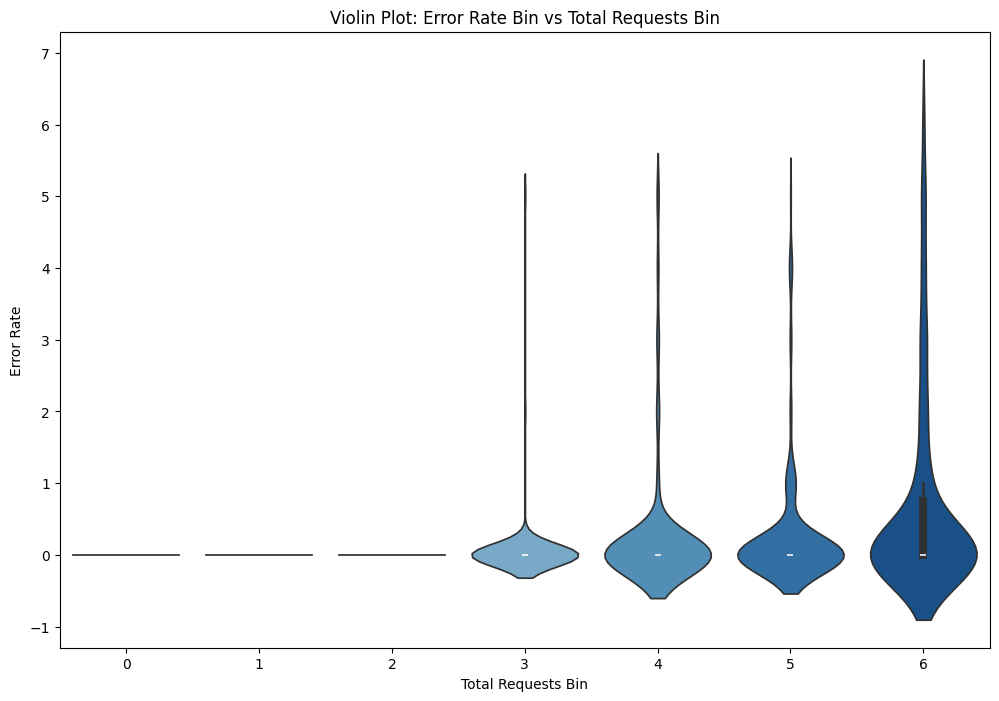

In [13]:
# Violin plot for 'ErrorRate_Bin' by 'TotalReq_bin' 
plt.figure(figsize=(12, 8))
sns.violinplot(x='total_req_bin', y='error_rate_bin', data=df, palette='Blues')
plt.title("Violin Plot: Error Rate Bin vs Total Requests Bin")
plt.xlabel("Total Requests Bin")
plt.ylabel("Error Rate")
plt.show()

In [31]:
# pearson correlation
correlation = df_kde_resampled['TotalReq'].corr(df_kde_resampled['ErrorRate'])

# Spearman correlation
spearman_corr = df_kde_resampled['TotalReq'].corr(df_kde_resampled['ErrorRate'], method='spearman')

# Kendall correlation
kendall_corr = df_kde_resampled['TotalReq'].corr(df_kde_resampled['ErrorRate'], method='kendall')

print(f"Spearman Correlation: {correlation}")
print(f"Spearman Correlation: {spearman_corr}")
print(f"Kendall Correlation: {kendall_corr}")

Spearman Correlation: 0.6071362923793681
Kendall Correlation: 0.47670961387604144
